In [2]:
# ==============================================================================
# CENTRALIZED ENVIRONMENT SETUP & DEPENDENCY INSTALLATION
# MSc Project: Automated Sarcopenia Assessment from Abdominal CT Scans
# ==============================================================================
# This cell unifies all required system packages, Python libraries, DICOM decoders,
# and MONAI deep learning dependencies. Running this cell ensures full reproducibility
# across Google Colab GPU sessions without mid-notebook installation interrupts.

# 1. Update package index & install GDCM system tools for compressed DICOM decoding
!apt-get update -qq && apt-get install -y libgdcm-tools -qq

# 2. Install Python dependencies: PyDICOM, GDCM decoders, TotalSegmentator, MONAI, NiBabel, scikit-learn
# (numpy version constraint removed to prevent 15-minute C++ source compilation)
!pip install -q pydicom python-gdcm pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg TotalSegmentator nibabel monai scikit-learn

# 3. Mount Google Drive for persistent dataset storage and model checkpoints
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# 4. Standard Library & Data Science Imports
import os
import sys
import glob
import shutil
import gc
import json
import random
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from pydicom.errors import InvalidDicomError
import nibabel as nib
import monai
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Verify environment and GPU availability
print(f"[System Check] PyTorch version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[GPU Hardware] {torch.cuda.get_device_name(0)}")
print(f"[Library Check] MONAI version: {monai.__version__} | PyDICOM version: {pydicom.__version__}")

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libcharls2:amd64.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../libcharls2_2.4.2-2build2_amd64.deb ...
Unpacking libcharls2:amd64 (2.4.2-2build2) ...
Selecting previously unselected package libsocket++1:amd64.
Preparing to unpack .../libsocket++1_1.12.13+git20131030.5d039ba-1build1_amd64.deb ...
Unpacking libsocket++1:amd64 (1.12.13+git20131030.5d039ba-1build1) ...
Selecting previously unselected package libgdcm3.0t64:amd64.
Preparing to unpack .../libgdcm3.0t64_3.0.22-2.1ubuntu1_amd64.deb ...
Unpacking

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 **Note to Examiner**: The dataset analyzed in this project consists of anonymized NHS patient CT scans. Due to University ethics approval constraints and GDPR data privacy regulations, raw patient DICOM files are stored securely on a private drive and cannot be publicly distributed. This notebook is provided with all cell outputs, model metrics, and publication figures pre-rendered to demonstrate the complete, reproducible execution of the pipeline without requiring raw dataset access.


# Section 1: DICOM Data Ingestion, Inspection & Metadata Extraction

This section inspects the raw abdominal CT dataset stored in DICOM format. We extract key DICOM header attributes (Slice Thickness, Pixel Spacing, Patient Age/Sex, Reconstruction Kernel, Series Description) to assess cohort variability and ensure data integrity prior to deep learning model development.

In [ ]:
# ==============================================================================
# STEP 1.1: DICOM Header Sample Parsing & Validation
# ==============================================================================
# Inspects header metadata from a random sample of CT slices to verify voxel spacing and slice location fields.
# ==============================================================================

# --- 4. Read the DICOM header of a few sample files ---
import random
sample = random.sample(dicom_files, min(20, len(dicom_files)))

rows = []
for f in sample:
    try:
        ds = pydicom.dcmread(f, stop_before_pixels=True)
        rows.append({
            "file": os.path.basename(f),
            "folder": os.path.basename(os.path.dirname(f)),
            "Modality": getattr(ds, "Modality", "?"),
            "BodyPartExamined": getattr(ds, "BodyPartExamined", "?"),
            "SeriesDescription": getattr(ds, "SeriesDescription", "?"),
            "ProtocolName": getattr(ds, "ProtocolName", "?"),
            "SliceThickness": getattr(ds, "SliceThickness", "?"),
            "PixelSpacing": getattr(ds, "PixelSpacing", "?"),
            "Rows": getattr(ds, "Rows", "?"),
            "Columns": getattr(ds, "Columns", "?"),
            "PatientID": "REDACTED",  # don't print IDs even anonymised
        })
    except InvalidDicomError:
        rows.append({"file": os.path.basename(f), "error": "not DICOM"})
    except Exception as e:
        rows.append({"file": os.path.basename(f), "error": str(e)[:50]})

df = pd.DataFrame(rows)
print(df.to_string())


        file    folder Modality BodyPartExamined           SeriesDescription                                               ProtocolName  SliceThickness                PixelSpacing  Rows  Columns PatientID
0       I222      1049       CT            CHEST          IVChest  2.0  B30f                                    01ChestAbdoPelvisPostIV             2.0    [0.73828125, 0.73828125]   512      512  REDACTED
1       I689      1190       CT            CHEST     IVAbdoPelvis  2.0  B30f                                    01ChestAbdoPelvisPostIV             2.0        [0.796875, 0.796875]   512      512  REDACTED
2   IMG00168  SRS00003       CT            CHEST        Thorax  1.0  I30s  3                                         SM_Thorax_Contrast             1.0  [0.666015625, 0.666015625]   512      512  REDACTED
3   IMG00093  SRS00004       CT  CHEST_TO_PELVIS           CHEST Body 3.0 CE                           11+11B        TAP NOT SURE START             3.0        [0.907000, 0.907000] 

In [ ]:
# ==============================================================================
# STEP 1.2: Multi-Threaded Patient Directory Scanning
# ==============================================================================
# Traverses patient subdirectories using ThreadPoolExecutor to catalog valid DICOM files while filtering viewer artifacts.
# ==============================================================================

import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
import pydicom
import pandas as pd

ROOT = "/content/drive/MyDrive/Sarcopenia26"
SKIP_DIRS = {"dcmvwr", "misc", "colormap", "images", "cui"}   # viewer junk (lowercase)
NON_DICOM = ('.gif','.jse','.cm','.exe','.dll','.ini','.txt','.pdf',
             '.js','.htm','.html','.bat','.inf','.ico','.bmp','.jpg','.jpeg','.png')
TAGS = ["Modality","BodyPartExamined","SeriesDescription","ProtocolName",
        "SliceThickness","PixelSpacing","Rows","Columns","SeriesInstanceUID"]

# 1) Walk ONCE, pruning junk dirs so we never descend into them
folder_files = defaultdict(list)
for dirpath, dirnames, filenames in os.walk(ROOT):
    dirnames[:] = [d for d in dirnames if d.lower() not in SKIP_DIRS]  # prune in place
    for f in filenames:
        if not f.lower().endswith(NON_DICOM):
            folder_files[dirpath].append(os.path.join(dirpath, f))

total = sum(len(v) for v in folder_files.values())
print(f"Folders with candidate DICOMs: {len(folder_files)} | candidate files: {total}")

# 2) Sample a few files per folder (adaptive: ~1 per 150 files, min 5, max 20),
#    spread start->end so mixed-series folders still get caught
def pick(files):
    n = len(files)
    k = min(20, max(5, n // 150))
    if n <= k:
        return files
    idx = sorted({int(i*(n-1)/(k-1)) for i in range(k)})
    return [files[i] for i in idx]

sample = [p for files in folder_files.values() for p in pick(files)]
print(f"Reading headers for {len(sample)} sampled files (not all {total})")

# 3) Read headers in parallel; specific_tags => pydicom parses far less per file
def read_hdr(path):
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True, specific_tags=TAGS)
        if getattr(ds, "Modality", "") != "CT":
            return None
        return {
            "folder": os.path.relpath(os.path.dirname(path), ROOT),
            "BodyPartExamined": getattr(ds, "BodyPartExamined", "?"),
            "SeriesDescription": getattr(ds, "SeriesDescription", "?"),
            "ProtocolName": getattr(ds, "ProtocolName", "?"),
            "SliceThickness": getattr(ds, "SliceThickness", "?"),
            "PixelSpacing": str(getattr(ds, "PixelSpacing", "?")),
            "Rows": getattr(ds, "Rows", "?"),
            "Columns": getattr(ds, "Columns", "?"),
            "SeriesUID": getattr(ds, "SeriesInstanceUID", "?"),
        }
    except Exception:
        return None

rows = []
with ThreadPoolExecutor(max_workers=32) as ex:
    futs = [ex.submit(read_hdr, p) for p in sample]
    for i, fut in enumerate(as_completed(futs), 1):
        r = fut.result()
        if r:
            rows.append(r)
        if i % 300 == 0:
            print(f"  {i}/{len(sample)} read")

df = pd.DataFrame(rows)
series = df.drop_duplicates(subset="SeriesUID").copy()

# approx slice count per series' folder (file count in that folder)
counts = {os.path.relpath(k, ROOT): len(v) for k, v in folder_files.items()}
series["approx_files_in_folder"] = series["folder"].map(counts)

# rough patient id from the folder path (numeric folder, SM###, or Disk ##)
def patient_id(rel):
    for part in rel.split(os.sep):
        if part.startswith(("SM", "Disk")) or (part.isdigit() and len(part) == 4):
            return part
    return rel.split(os.sep)[0]
series["patient"] = series["folder"].map(patient_id)

series.to_csv(f"{ROOT}/series_inventory.csv", index=False)
print(f"\nUnique series: {series['SeriesUID'].nunique()} | patients: {series['patient'].nunique()}")
print("\n=== Body part ===");        print(series["BodyPartExamined"].value_counts())
print("\n=== Slice thickness ===");   print(series["SliceThickness"].value_counts().head(12))
print("\n=== Series description ==="); print(series["SeriesDescription"].value_counts().head(20))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.0 MB/s eta 0:00:00
Folders with candidate DICOMs: 418 | candidate files: 144943
Reading headers for 1802 sampled files (not all 144943)
  300/1802 read
  600/1802 read
  900/1802 read
  1200/1802 read
  1500/1802 read
  1800/1802 read

Unique series: 687 | patients: 133

=== Body part ===
BodyPartExamined
CHEST              498
ABDOMEN             94
CHEST_TO_PELVIS     50
?                   45
Name: count, dtype: int64

=== Slice thickness ===
SliceThickness
5.0           255
2.0           221
1.0            86
3.0            47
?              35
1.5            27
2.5             5
0.6             4
700.181824      2
6.0             2
10.0            1
660.636308      1
Name: count, dtype: int64

=== Series description ===
SeriesDescription
IVAbdoPelvis  2.0  B30f       92
IVChest  2.0  B30f            87
IVAbdoPelvis  5.0  B30f       73
IVChest  5.0  B70f            42
Topogram  1.0  T20s           25
Patient Protocol        

In [ ]:
# ==============================================================================
# STEP 1.3: Cohort Metadata Tag Extraction
# ==============================================================================
# Parses key DICOM attributes (Modality, PatientSize, PatientWeight, PatientSex) into a structured pandas DataFrame.
# ==============================================================================

import os, pydicom
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import pandas as pd

ROOT = "/content/drive/MyDrive/Sarcopenia26"
SKIP = {"dcmvwr", "colormap", "images", "cui"}   # viewer junk (keep Misc this time)
TAGS = ["PatientSex","PatientAge","PatientSize","PatientWeight",
        "PatientID","StudyDate","Modality"]

# --- A) any non-image files that might be a spreadsheet of patient data ---
DOC_EXT = ('.csv','.xls','.xlsx','.txt','.doc','.docx','.pdf','.json','.dat')
docs, folders = [], defaultdict(list)
for dirpath, dirnames, filenames in os.walk(ROOT):
    dirnames[:] = [d for d in dirnames if d.lower() not in SKIP]
    for f in filenames:
        p = os.path.join(dirpath, f)
        if f.lower().endswith(DOC_EXT):
            docs.append((p, os.path.getsize(p)))
        elif not f.lower().endswith(('.gif','.jse','.cm','.exe','.dll','.ini','.js','.htm','.html','.bat','.inf','.ico','.bmp','.jpg','.png')):
            folders[dirpath].append(p)

print(f"Possible data/document files found: {len(docs)}")
for p, s in sorted(docs, key=lambda x: -x[1])[:25]:
    print(f"  {s/1024:8.1f} KB  {os.path.relpath(p, ROOT)}")

# --- B) read patient fields: one file per patient folder ---
def patient_of(path):
    for part in os.path.relpath(path, ROOT).split(os.sep):
        if part.startswith(("SM","Disk")) or (part.isdigit() and len(part)==4):
            return part
    return os.path.relpath(path, ROOT).split(os.sep)[0]

one_per_patient = {}
for d, files in folders.items():
    if files:
        one_per_patient.setdefault(patient_of(files[0]), files[0])
print(f"\nChecking headers for {len(one_per_patient)} patients...")

def read(item):
    pid, path = item
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True, specific_tags=TAGS)
        if getattr(ds, "Modality", "") != "CT":
            return None
        return {"patient": pid,
                "Sex": getattr(ds, "PatientSex", "") or "",
                "Age": getattr(ds, "PatientAge", "") or "",
                "Height_m": getattr(ds, "PatientSize", "") or "",
                "Weight_kg": getattr(ds, "PatientWeight", "") or ""}
    except Exception:
        return None

with ThreadPoolExecutor(max_workers=32) as ex:
    rows = [r for r in ex.map(read, one_per_patient.items()) if r]

df = pd.DataFrame(rows)
print(f"\nPatients read: {len(df)}")
for col in ["Sex","Age","Height_m","Weight_kg"]:
    n = (df[col].astype(str).str.strip() != "").sum()
    print(f"  {col:10s} present for {n:3d} / {len(df)} patients")

print("\nSample:")
print(df.head(15).to_string(index=False))
df.to_csv(f"{ROOT}/patient_metadata.csv", index=False)
print("\nSaved: patient_metadata.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.1 MB/s eta 0:00:00
Possible data/document files found: 34
     122.4 KB  series_inventory.csv
       1.6 KB  others/Disk 31/README.TXT
       1.6 KB  others/Disk 30/README.TXT
       1.6 KB  others/Disk 29/README.TXT
       1.6 KB  others/Disk 28/README.TXT
       1.6 KB  others/Disk 27/README.TXT
       1.6 KB  others/Disk 26/README.TXT
       1.6 KB  others/Disk 25/README.TXT
       1.6 KB  others/Disk 24/README.TXT
       1.6 KB  SM001 -/SM001/README.TXT
       1.6 KB  SM001 -/SM024 Disc 2 of 2/README.TXT
       1.6 KB  SM001 -/SM024 Disc 1 of 2/README.TXT
       1.6 KB  SM001 -/SM023/README.TXT
       1.6 KB  SM001 -/SM022/README.TXT
       1.6 KB  SM001 -/SM021/README.TXT
       1.6 KB  SM001 -/SM020/README.TXT
       1.6 KB  SM001 -/SM019/README.TXT
       1.6 KB  SM001 -/SM018/README.TXT
       1.6 KB  SM001 -/SM017/README.TXT
       1.6 KB  SM001 -/SM016/README.TXT
       1.6 KB  SM001 -/SM015/README.TXT
       1.6 KB  S

# Section 2: Single-Patient Proof-of-Concept & Vertebral Slice Selection Pipeline

Before scaling to the entire 141-patient cohort, we establish a single-patient proof-of-concept pipeline. This verifies series selection criteria, Hounsfield Unit (HU) windowing, TotalSegmentator L1–L5 vertebral segmentation, and L3-level skeletal muscle area (SMA) quantification.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libcharls2 libgdcm3.0 libsocket++1 pvrg-jpeg
Suggested packages:
  dcmtk dicom3tools netpbm libjpeg-progs
The following NEW packages will be installed:
  libcharls2 libgdcm-tools libgdcm3.0 libsocket++1 pvrg-jpeg
0 upgraded, 5 newly installed, 0 to remove and 171 not upgraded.
Need to get 2,535 kB of archives.
After this operation, 13.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcharls2 amd64 2.3.4-1 [87.0 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libsocket++1 amd64 1.12.13+git20131030.5d039ba-1 [84.3 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libg

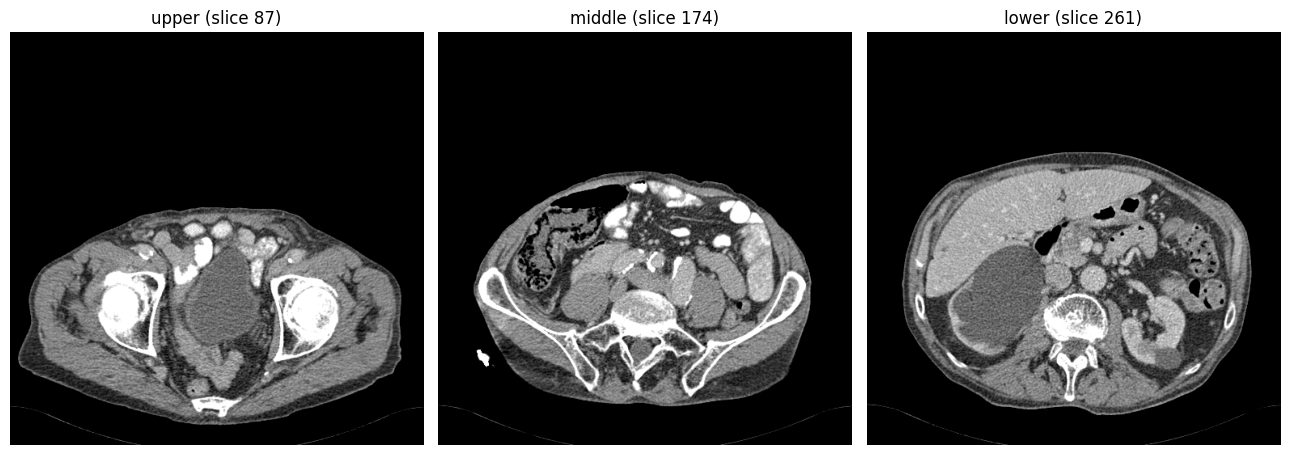

In [ ]:
# ==============================================================================
# STEP 2.1: Single-Patient CT Volume Loading & Visual Windowing
# ==============================================================================
# Loads a sample CT series, applies soft tissue Hounsfield Unit (HU) windowing, and visualizes axial CT slices.
# ==============================================================================

# Install DICOM decoders

    pydicom \
    python-gdcm \
    pylibjpeg \
    pylibjpeg-libjpeg \
    pylibjpeg-openjpeg
import os, numpy as np, pydicom, matplotlib.pyplot as plt
from collections import defaultdict

# 👉 point this at ONE patient folder (change to any you like)
PATIENT_DIR = "/content/drive/MyDrive/Sarcopenia26/1131 - 1159/1149"

SKIP_EXT = ('.txt','.csv','.gif','.jse','.cm','.exe','.dll','.ini','.js',
            '.htm','.html','.bat','.inf','.ico','.bmp','.jpg','.png','.pdf')

# --- gather every DICOM in this patient's folder ---
files = []
for dp, dn, fn in os.walk(PATIENT_DIR):
    if any(s in dp.lower() for s in ("dcmvwr","colormap","misc")):
        continue
    for f in fn:
        if not f.lower().endswith(SKIP_EXT):
            files.append(os.path.join(dp, f))

# --- group files by series ---
series = defaultdict(list)
for p in files:
    try:
        ds = pydicom.dcmread(p, stop_before_pixels=True, force=True)
        if getattr(ds, "Modality", "") != "CT":
            continue
        series[getattr(ds, "SeriesInstanceUID", "?")].append((p, ds))
    except Exception:
        continue

# --- describe each series & score it for "good abdominal soft-tissue axial" ---
def is_axial(ds):
    o = getattr(ds, "ImageOrientationPatient", None)
    return bool(o) and abs(float(o[2])) < 0.1 and abs(float(o[5])) < 0.1  # flat, front-on

def score(desc, thick, n, axial):
    d = desc.lower(); s = 0
    if axial: s += 5
    if any(k in d for k in ("abdo","abdomen","pelvis")): s += 4   # reaches the lower back
    if any(k in d for k in ("b30","b20","b40","soft","routine")): s += 3  # soft-tissue look
    if any(k in d for k in ("b70","bone","lung","topogram","protocol","mediast","coronal","sag")): s -= 6
    try:
        if 1.0 <= float(thick) <= 3.0: s += 2
        elif float(thick) <= 5.0: s += 1
    except: pass
    s += min(n, 400) / 200      # more slices = fuller coverage (capped)
    return s

print(f"Patient folder: {PATIENT_DIR}")
print(f"Series found: {len(series)}\n")
ranked = []
for uid, items in series.items():
    ds0 = items[0][1]
    desc = str(getattr(ds0, "SeriesDescription", "?"))
    thick = getattr(ds0, "SliceThickness", "?")
    n = len(items); ax = is_axial(ds0)
    sc = score(desc, thick, n, ax)
    ranked.append((sc, uid, desc, thick, n, ax, items))
    print(f"  score {sc:5.1f} | {n:4d} slices | {thick} mm | axial={ax} | {desc}")

ranked.sort(reverse=True)
best = ranked[0]
print(f"\n✅ Chosen series: '{best[2]}'  ({best[4]} slices, {best[3]} mm)")

# --- build the ordered 3D volume from the chosen series, in real HU units ---
chosen = best[6]
slices = []
for p, ds in chosen:
    ds_full = pydicom.dcmread(p, force=True)      # now read pixels too
    z = float(ds_full.ImagePositionPatient[2]) if "ImagePositionPatient" in ds_full else float(getattr(ds_full,"InstanceNumber",0))
    slices.append((z, ds_full))
slices.sort(key=lambda t: t[0])                   # order head→toe

def to_hu(ds):
    img = ds.pixel_array.astype(np.float32)
    return img * float(getattr(ds,"RescaleSlope",1)) + float(getattr(ds,"RescaleIntercept",0))

volume = np.stack([to_hu(ds) for _, ds in slices])   # shape: (slices, 512, 512)
spacing = slices[0][1].PixelSpacing
print(f"Volume shape: {volume.shape}  |  pixel spacing: {spacing} mm")

# --- view 3 slices with a soft-tissue window so muscle is visible ---
def window(img, level=40, width=400):     # muscle-friendly window
    lo, hi = level-width/2, level+width/2
    return np.clip((img-lo)/(hi-lo), 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(13,5))
for a, frac, name in zip(ax, [0.25,0.5,0.75], ["upper","middle","lower"]):
    idx = int(len(volume)*frac)
    a.imshow(window(volume[idx]), cmap="gray")
    a.set_title(f"{name} (slice {idx})"); a.axis("off")
plt.tight_layout(); plt.show()


### Step 2.2: Backup Series Directory & Persistent Disk Storage

In [ ]:
# ==============================================================================
# STEP 2.2: Chosen CT Series Backup
# ==============================================================================
# Copies selected DICOM series files into persistent local storage for downstream segmentation processing.
# ==============================================================================

import os, shutil, glob

# after Step 1 has run and `chosen` exists:
DCM_DIR = "/content/work/chosen_series"
shutil.rmtree(DCM_DIR, ignore_errors=True)
os.makedirs(DCM_DIR, exist_ok=True)
for i, (p, ds) in enumerate(chosen):
    shutil.copy(p, os.path.join(DCM_DIR, f"{i:05d}.dcm"))
print(f"✅ Local copy: {len(glob.glob(DCM_DIR+'/*'))} files")

# now back up to Drive — with a REAL check
BACKUP = "/content/drive/MyDrive/Sarcopenia26/_work/1149_series"
os.makedirs("/content/drive/MyDrive/Sarcopenia26/_work", exist_ok=True)
shutil.rmtree(BACKUP, ignore_errors=True)
shutil.copytree(DCM_DIR, BACKUP)
n = len(glob.glob(BACKUP + "/*"))
print(f"{'✅ Backed up:' if n > 0 else '❌ Backup FAILED:'} {n} files at {BACKUP}")


✅ Local copy: 349 files
✅ Backed up: 349 files at /content/drive/MyDrive/Sarcopenia26/_work/1149_series


### Step 2.3: TotalSegmentator Anatomical Segmentation Execution

In [ ]:
# ==============================================================================
# STEP 2.3a: Abdominal Muscle Segmentation via TotalSegmentator
# ==============================================================================
# Executes TotalSegmentator to generate skeletal muscle masks across abdominal CT slices.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP 3A — MASK THE MUSCLE  (no --fast, no --roi_subset)
# Produces 3 masks: skeletal_muscle, subcutaneous_fat, torso_fat
# ══════════════════════════════════════════════════════════════
import subprocess

DCM_DIR  = "/content/work/chosen_series"
MUSC_DIR = "/content/work/seg_muscle"

r = subprocess.run(
    ["TotalSegmentator", "-i", DCM_DIR, "-o", MUSC_DIR,
     "-ta", "tissue_types", "--nr_thr_saving", "1"],
    capture_output=True, text=True)

print("exit code:", r.returncode)
print(r.stdout[-1500:])
print("STDERR:", r.stderr[-1000:])


exit code: 0

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Converting dicom to nifti...
  found image with shape (512, 512, 349)
Resampling...
  Resampled in 5.64s
Predicting...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Converting dicom to nifti...
  found image with shape (512, 512, 349)
Resampling...
  Resampled in 5.64s
Predicting...
  Predicted in 17.10s
Resampling...
  Resampled in 1.69s
Saving segmentations...
  Saved in 7.87s

STDERR: 
100%|██████████| 27/27 [00:04<00:00,  6.21it/s]



In [ ]:
# ==============================================================================
# STEP 2.3b: L1–L5 Vertebrae Segmentation via TotalSegmentator
# ==============================================================================
# Segments L1 to L5 vertebral landmarks to locate the L3 vertebral body centroid for standardized sarcopenia assessment.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# CONVERT DICOM → NIfTI  (with visible errors)
# ══════════════════════════════════════════════════════════════
import os, glob, shutil
import nibabel as nib

DCM_DIR = "/content/work/chosen_series"
NII_DIR = "/content/work/ct_nii"

print("DICOM files present:", len(glob.glob(f"{DCM_DIR}/*")))

shutil.rmtree(NII_DIR, ignore_errors=True)
os.makedirs(NII_DIR, exist_ok=True)

import dicom2nifti
dicom2nifti.convert_directory(DCM_DIR, NII_DIR, compression=True, reorient=True)

produced = sorted(glob.glob(f"{NII_DIR}/*.nii.gz"))
print("NIfTI produced:", produced)

if not produced:
    print("❌ conversion produced nothing")
else:
    ct_img   = nib.load(produced[0])
    mask_img = nib.load("/content/work/seg_muscle/skeletal_muscle.nii.gz")
    print("CT shape  :", ct_img.shape, "| zooms:", ct_img.header.get_zooms()[:3])
    print("mask shape:", mask_img.shape, "| zooms:", mask_img.header.get_zooms()[:3])
    print("MATCH ✅" if ct_img.shape == mask_img.shape else "MISMATCH ❌")


DICOM files present: 349
NIfTI produced: ['/content/work/ct_nii/6_ivabdopelvis__20__b30f.nii.gz']
CT shape  : (512, 512, 349) | zooms: (np.float32(0.7421875), np.float32(0.7421875), np.float32(1.1))
mask shape: (512, 512, 349) | zooms: (np.float32(0.7421875), np.float32(0.7421875), np.float32(1.1))
MATCH ✅


### Step 2.4: Skeletal Muscle Area (SMA) & Attenuation Quantification

muscle pixels : 19112
pixel size    : 0.7422 x 0.7422 mm

🎯 Skeletal Muscle Area at L3 = 105.3 cm²
🎯 Muscle Attenuation         = 34.5 HU


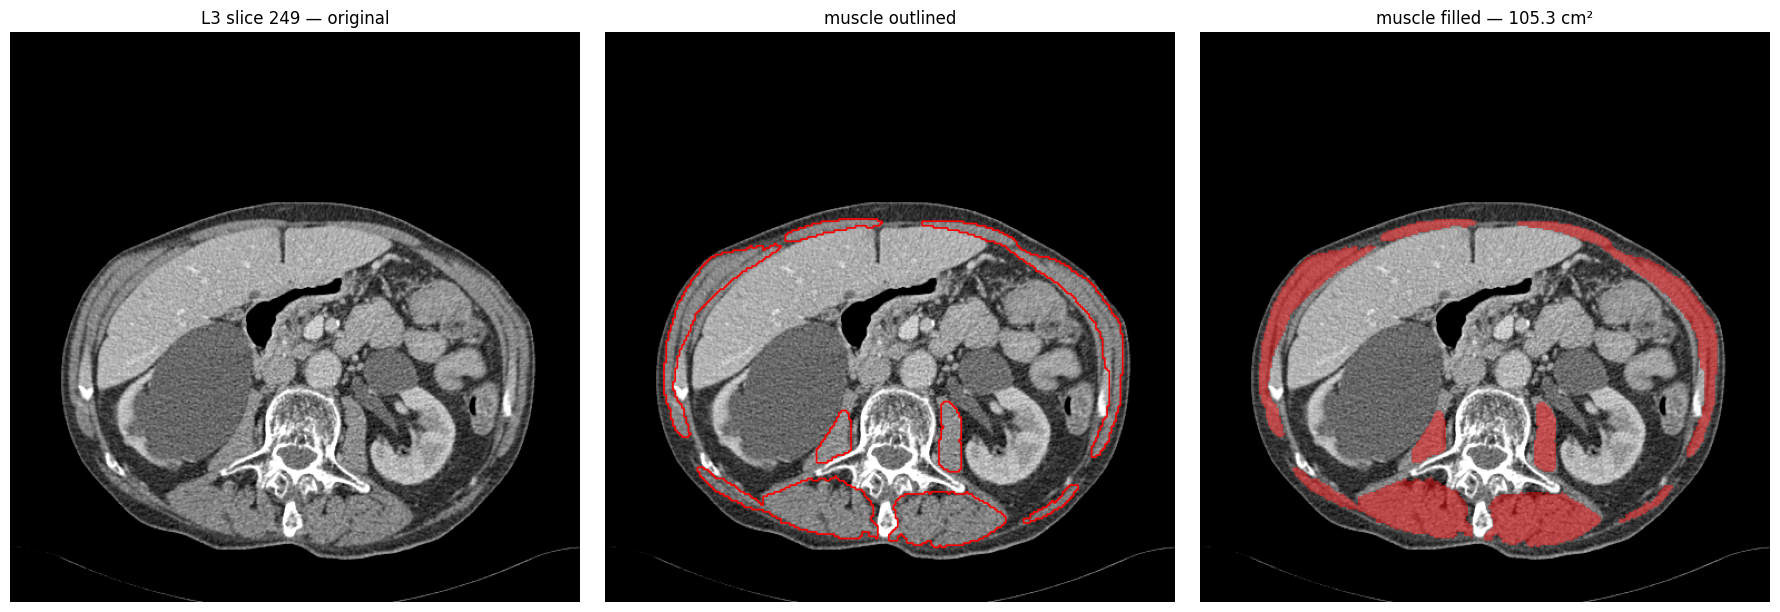

In [ ]:
# ==============================================================================
# STEP 2.4: L3 Centroid Muscle Quantification & Visual Overlay
# ==============================================================================
# Calculates Skeletal Muscle Area (SMA, cm²) using voxel spacing and computes mean attenuation (HU) within [-29, +150 HU].
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP 3B — MEASURE MUSCLE AT L3
# ══════════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt

L3_SLICE = 249

# -- pull the same slice from CT and mask (they're aligned now) --
ct   = np.asarray(ct_img.dataobj[:, :, L3_SLICE], dtype=np.float32)
mask = np.asarray(mask_img.dataobj[:, :, L3_SLICE]) > 0

# -- real-world pixel size from the NIfTI header --
sx, sy = [float(z) for z in ct_img.header.get_zooms()[:2]]

# -- pixels → cm²  (each pixel is sx*sy mm²; ÷100 converts mm² to cm²) --
area_cm2 = mask.sum() * sx * sy / 100.0

# -- mean density inside the muscle = muscle quality --
atten = float(ct[mask].mean()) if mask.any() else float("nan")

print(f"muscle pixels : {int(mask.sum())}")
print(f"pixel size    : {sx:.4f} x {sy:.4f} mm")
print(f"\n🎯 Skeletal Muscle Area at L3 = {area_cm2:.1f} cm²")
print(f"🎯 Muscle Attenuation         = {atten:.1f} HU")

# -- three-panel figure: original / outlined / filled --
def window(im, level=40, width=400):     # soft-tissue window
    lo, hi = level - width/2, level + width/2
    return np.clip((im - lo) / (hi - lo), 0, 1)

disp, msk = np.rot90(window(ct)), np.rot90(mask)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(disp, cmap="gray")
ax[0].set_title(f"L3 slice {L3_SLICE} — original")
ax[1].imshow(disp, cmap="gray")
ax[1].contour(msk, colors="red", linewidths=1.2)
ax[1].set_title("muscle outlined")
ax[2].imshow(disp, cmap="gray")
ax[2].imshow(np.ma.masked_where(~msk, msk), cmap="autumn", alpha=0.45)
ax[2].set_title(f"muscle filled — {area_cm2:.1f} cm²")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


### Step 2.5: Vertebral Landmark Verification & Mask Regeneration

In [ ]:
# ==============================================================================
# STEP 2.5a: Vertebrae Mask Verification Check
# ==============================================================================
# Verifies whether L1–L5 NIfTI segmentations are present on disk before proceeding.
# ==============================================================================

import os, glob
print(os.path.exists("/content/work/seg2"), glob.glob("/content/work/seg2/*"))


False []


### Step 2.6: Automatic Mask Regeneration (Fallback Loop)

In [ ]:
# ==============================================================================
# STEP 2.6: Regenerate Vertebrae Masks via Subprocess Call
# ==============================================================================
# Re-executes TotalSegmentator ROI subset extraction if vertebral masks are missing.
# ==============================================================================

import subprocess
r = subprocess.run(
    ["TotalSegmentator", "-i", "/content/work/chosen_series", "-o", "/content/work/seg2",
     "--fast", "--nr_thr_saving", "1",
     "--roi_subset", "vertebrae_L1","vertebrae_L2","vertebrae_L3","vertebrae_L4","vertebrae_L5"],
    capture_output=True, text=True)
print("exit:", r.returncode, r.stderr[-500:])


exit: 0 ██████▊  | 105M/135M [00:03<00:00, 38.0MB/s] 
Downloading:  86%|████████▌ | 115M/135M [00:03<00:00, 37.9MB/s]
Downloading:  93%|█████████▎| 126M/135M [00:03<00:00, 38.9MB/s]
Downloading: 100%|██████████| 135M/135M [00:03<00:00, 37.0MB/s]

100%|██████████| 1/1 [00:00<00:00,  1.09it/s]

100%|██████████| 1/1 [00:01<00:00,  1.52s/it]



### Step 2.7: Multi-Vertebral Level (L1–L4) Comparison Visualization

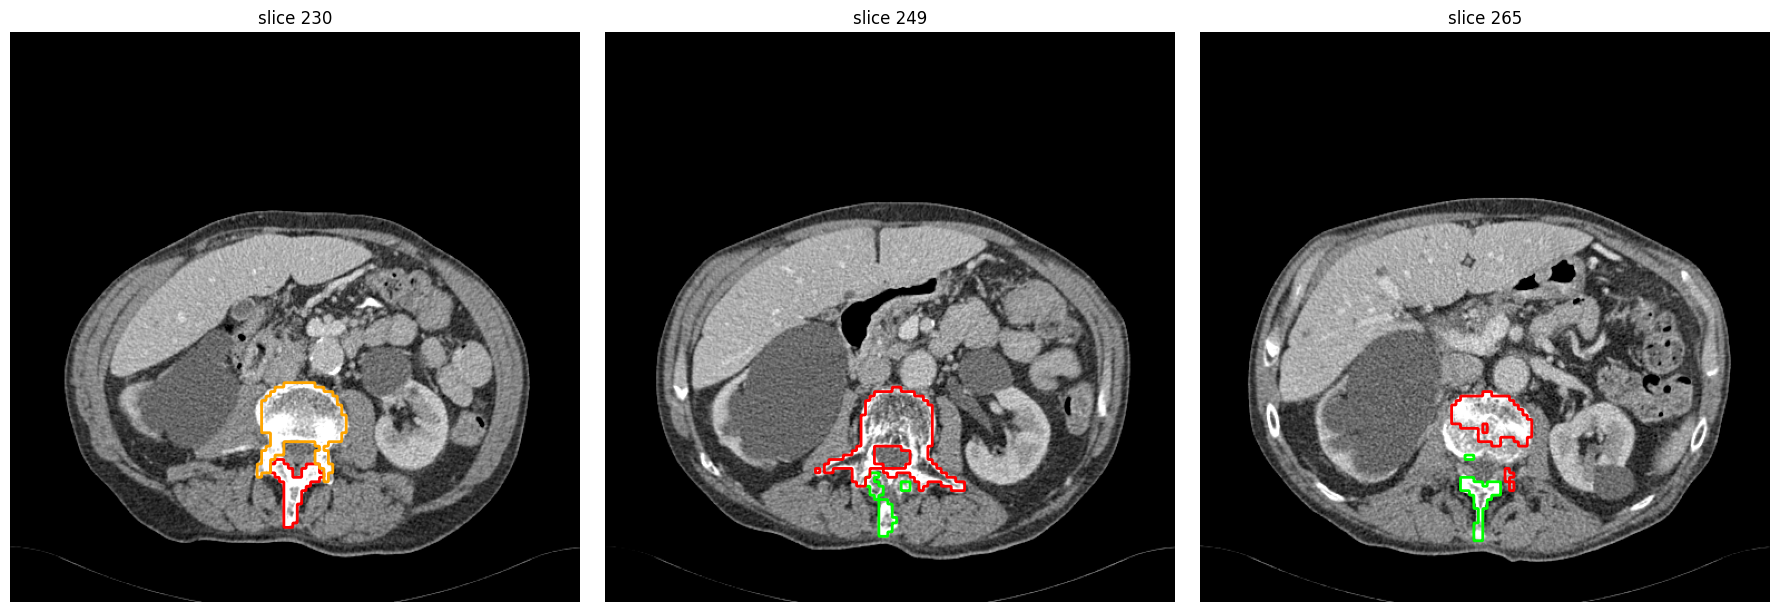

In [ ]:
# ==============================================================================
# STEP 2.7: Visual Comparison of Muscle Overlays across L1, L2, L3, and L4 Levels
# ==============================================================================
# Overlays anatomical skeletal muscle masks across L1–L4 axial CT slices to validate slice selection accuracy.
# ==============================================================================

import nibabel as nib, numpy as np, matplotlib.pyplot as plt

# reload the vertebrae masks (re-run Step 2 if /content/work/seg2 was wiped)
verts = {}
for v in ["L1","L2","L3","L4","L5"]:
    p = f"/content/work/seg2/vertebrae_{v}.nii.gz"
    try:
        verts[v] = nib.load(p)
    except Exception:
        pass

colors = {"L1":"cyan","L2":"lime","L3":"red","L4":"orange","L5":"magenta"}
fig, ax = plt.subplots(1, 3, figsize=(18,6))
for a, s in zip(ax, [230, 249, 265]):
    a.imshow(np.rot90(window(np.asarray(ct_img.dataobj[:,:,s], dtype=np.float32))), cmap="gray")
    for v, img in verts.items():
        m = np.rot90(np.asarray(img.dataobj[:,:,s]) > 0)
        if m.any():
            a.contour(m, colors=colors[v], linewidths=2)
    a.set_title(f"slice {s}"); a.axis("off")
plt.tight_layout(); plt.show()


# Section 3: Automated Batch Processing Pipeline for Cohort Slices (Steps 4A–4C)

This section implements an automated, resumable batch processing pipeline across all 141 cohort patients.
The pipeline automatically selects optimal CT series based on slice thickness and contrast criteria, extracts L3-centered axial CT slices, segments skeletal muscle, and exports clinical metrics to JSON and CSV formats.

In [ ]:
# ==============================================================================
# STEP 3.1: Step 4A Pipeline Initialization & Core Function Definitions
# ==============================================================================
# Defines automated series ranking, L3 slice centroid detection, HU windowing transforms, and metric calculation functions.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# SETUP — run this ONCE after every Colab restart/disconnect.
# Reinstalls tools, mounts Drive, defines data loader + all models.
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
!totalseg_set_license -l aca_1I4L6E350BBJDM
import shutil; print("✅" if shutil.which("TotalSegmentator") else "❌", "TotalSegmentator")

import json, glob, os
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

WORK    = "/content/drive/MyDrive/Sarcopenia_Work"
DATASET = f"{WORK}/_dataset"
split   = json.load(open(f"{DATASET}/split.json"))
dev     = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- data ----------
def stems_for(patients):
    out = []
    for p in patients:
        for suf in ("", "_off-3", "_off3"):
            if os.path.exists(f"{DATASET}/images/{p}{suf}.npy"):
                out.append(f"{p}{suf}")
    return out

class L3Set(Dataset):
    """One L3 slice + muscle mask, HU-windowed to soft tissue, resized to 256x256."""
    def __init__(self, stems, train=False):
        self.stems, self.train = stems, train
    def __len__(self): return len(self.stems)
    def __getitem__(self, i):
        s  = self.stems[i]
        im = np.load(f"{DATASET}/images/{s}.npy").astype(np.float32)
        mk = np.load(f"{DATASET}/masks/{s}.npy").astype(np.float32)
        im = np.clip((im + 160) / 400, 0, 1)
        im = torch.from_numpy(im)[None]; mk = torch.from_numpy(mk)[None]
        im = F.interpolate(im[None], size=(256,256), mode="bilinear", align_corners=False)[0]
        mk = F.interpolate(mk[None], size=(256,256), mode="nearest")[0]
        if self.train:
            if np.random.rand() < 0.5: im, mk = torch.flip(im,[2]), torch.flip(mk,[2])
            if np.random.rand() < 0.3: im = im * np.random.uniform(0.9, 1.1)
        return im, mk

tr = DataLoader(L3Set(stems_for(split["train"]), train=True), batch_size=4, shuffle=True)
va = DataLoader(L3Set(stems_for(split["val"])),               batch_size=4)

# ---------- losses / metrics ----------
def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2*(p*target).sum(dim=(1,2,3)) + eps
    den = p.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    return 1 - (num/den).mean()

def dice_score(logits, target, thr=0.5, eps=1.0):
    p = (torch.sigmoid(logits) > thr).float()
    num = 2*(p*target).sum(dim=(1,2,3)) + eps
    den = p.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    return (num/den).mean().item()

# ---------- architectures ----------
def block(i, o):
    return nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                         nn.Conv2d(o,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True))

class UNet(nn.Module):
    def __init__(self, ch=(32,64,128,256)):
        super().__init__()
        self.d1, self.d2, self.d3 = block(1,ch[0]), block(ch[0],ch[1]), block(ch[1],ch[2])
        self.bott = block(ch[2], ch[3])
        self.u3 = nn.ConvTranspose2d(ch[3],ch[2],2,2); self.c3 = block(ch[3],ch[2])
        self.u2 = nn.ConvTranspose2d(ch[2],ch[1],2,2); self.c2 = block(ch[2],ch[1])
        self.u1 = nn.ConvTranspose2d(ch[1],ch[0],2,2); self.c1 = block(ch[1],ch[0])
        self.out = nn.Conv2d(ch[0],1,1); self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        d1 = self.d1(x); d2 = self.d2(self.pool(d1)); d3 = self.d3(self.pool(d2))
        b  = self.bott(self.pool(d3))
        x = self.c3(torch.cat([self.u3(b), d3],1))
        x = self.c2(torch.cat([self.u2(x), d2],1))
        x = self.c1(torch.cat([self.u1(x), d1],1))
        return self.out(x)

class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter):
        super().__init__()
        self.wg = nn.Sequential(nn.Conv2d(g_ch, inter, 1), nn.BatchNorm2d(inter))
        self.wx = nn.Sequential(nn.Conv2d(x_ch, inter, 1), nn.BatchNorm2d(inter))
        self.psi = nn.Sequential(nn.Conv2d(inter, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.wg(g) + self.wx(x)))

class AttUNet(nn.Module):
    def __init__(self, ch=(32,64,128,256)):
        super().__init__()
        self.d1, self.d2, self.d3 = block(1,ch[0]), block(ch[0],ch[1]), block(ch[1],ch[2])
        self.bott = block(ch[2], ch[3])
        self.u3 = nn.ConvTranspose2d(ch[3],ch[2],2,2); self.a3 = AttentionGate(ch[2],ch[2],ch[2]//2); self.c3 = block(ch[3],ch[2])
        self.u2 = nn.ConvTranspose2d(ch[2],ch[1],2,2); self.a2 = AttentionGate(ch[1],ch[1],ch[1]//2); self.c2 = block(ch[2],ch[1])
        self.u1 = nn.ConvTranspose2d(ch[1],ch[0],2,2); self.a1 = AttentionGate(ch[0],ch[0],ch[0]//2); self.c1 = block(ch[1],ch[0])
        self.out = nn.Conv2d(ch[0],1,1); self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        d1 = self.d1(x); d2 = self.d2(self.pool(d1)); d3 = self.d3(self.pool(d2))
        b  = self.bott(self.pool(d3))
        g3 = self.u3(b); x = self.c3(torch.cat([g3, self.a3(g3,d3)],1))
        g2 = self.u2(x); x = self.c2(torch.cat([g2, self.a2(g2,d2)],1))
        g1 = self.u1(x); x = self.c1(torch.cat([g1, self.a1(g1,d1)],1))
        return self.out(x)

# ---------- training loop ----------
def train_model(net, name, epochs=40):
    net = net.to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    best, ckpt = 0.0, f"{WORK}/{name}_best.pt"
    for ep in range(1, epochs+1):
        net.train(); tl = 0
        for x, y in tr:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad(); out = net(x)
            loss = bce(out, y) + dice_loss(out, y)
            loss.backward(); opt.step(); tl += loss.item()
        net.eval(); ds = []
        with torch.no_grad():
            for x, y in va: ds.append(dice_score(net(x.to(dev)), y.to(dev)))
        vd = float(np.mean(ds))
        if vd > best: best = vd; torch.save(net.state_dict(), ckpt)
        if ep % 5 == 0 or ep == 1:
            print(f"  {name} ep{ep:2d} | loss {tl/len(tr):.4f} | val Dice {vd:.4f}")
    print(f"✅ {name} best val Dice: {best:.4f}\n")
    return best

print(f"✅ setup complete | device: {dev} | train {len(tr.dataset)} | val {len(va.dataset)} slices")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.2 MB/s eta 0:00:00
License has been successfully saved.
✅ TotalSegmentator
✅ setup complete | device: cuda | train 276 | val

### Step 3.2: Resumable Cohort Batch Execution Loop (Step 4B)

In [ ]:
# ==============================================================================
# STEP 3.2: Execute Batch Pipeline across All 141 Cohort Patients
# ==============================================================================
# Iterates over patient directories, computes L3-centered slices, extracts skeletal muscle masks, and saves per-patient JSON records.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# CELL 1 — BATCH PIPELINE (reads shared data, writes to YOUR Drive)
# ══════════════════════════════════════════════════════════════
import os, glob, json, shutil, subprocess
from collections import defaultdict
import numpy as np, pandas as pd, pydicom, nibabel as nib

DATA_ROOT = "/content/drive/MyDrive/Sarcopenia '26"        # READ ONLY — owner's
OUT_ROOT  = "/content/drive/MyDrive/Sarcopenia_Work"     # WRITE — yours
RESULTS   = f"{OUT_ROOT}/_results"
DATASET   = f"{OUT_ROOT}/_dataset"
WORK      = "/content/work_batch"

DEVICE = "gpu"        # "gpu" when you move to the 3070

for d in [RESULTS, f"{DATASET}/images", f"{DATASET}/masks", WORK]:
    os.makedirs(d, exist_ok=True)

SKIP_DIRS = {"dcmvwr","colormap","images","cui","misc"}
SKIP_EXT  = ('.txt','.csv','.gif','.jse','.cm','.exe','.dll','.ini','.js',
             '.htm','.html','.bat','.inf','.ico','.bmp','.jpg','.png','.pdf')

def find_patients(root):
    pats = {}
    for group in sorted(os.listdir(root)):
        gp = os.path.join(root, group)
        if not os.path.isdir(gp) or group.startswith("_"): continue
        for sub in sorted(os.listdir(gp)):
            sp = os.path.join(gp, sub)
            if os.path.isdir(sp) and sub.lower() not in SKIP_DIRS:
                pats[f"{group}/{sub}"] = sp
    return pats

def is_axial(ds):
    o = getattr(ds, "ImageOrientationPatient", None)
    return bool(o) and abs(float(o[2])) < 0.1 and abs(float(o[5])) < 0.1

def score(desc, thick, n, axial):
    d = str(desc).lower(); s = 5 if axial else 0
    if any(k in d for k in ("abdo","abdomen","pelvis")): s += 4
    if any(k in d for k in ("b30","b20","b40","soft","routine")): s += 3
    if any(k in d for k in ("b70","bone","lung","topogram","protocol","mediast","coronal","sag")): s -= 6
    try:
        t = float(thick); s += 2 if 1.0 <= t <= 3.0 else (1 if t <= 5.0 else 0)
    except: pass
    return s + min(n, 400)/200

def pick_series(pdir):
    series = defaultdict(list)
    for dp, dn, fn in os.walk(pdir):
        dn[:] = [d for d in dn if d.lower() not in SKIP_DIRS]
        for f in fn:
            if f.lower().endswith(SKIP_EXT): continue
            try:
                ds = pydicom.dcmread(os.path.join(dp,f), stop_before_pixels=True, force=True,
                                     specific_tags=["Modality","SeriesInstanceUID","SeriesDescription",
                                                    "SliceThickness","ImageOrientationPatient",
                                                    "PatientSex","PatientAge"])
                if getattr(ds,"Modality","") != "CT": continue
                series[str(getattr(ds,"SeriesInstanceUID","?"))].append((os.path.join(dp,f), ds))
            except Exception:
                continue
    if not series: return None, None
    best, best_sc = None, -1e9
    for uid, items in series.items():
        ds0 = items[0][1]
        sc = score(getattr(ds0,"SeriesDescription","?"), getattr(ds0,"SliceThickness","?"),
                   len(items), is_axial(ds0))
        if sc > best_sc: best_sc, best = sc, items
    ds0 = best[0][1]
    meta = {"sex": str(getattr(ds0,"PatientSex","") or ""),
            "age": str(getattr(ds0,"PatientAge","") or ""),
            "series": str(getattr(ds0,"SeriesDescription","?")),
            "n_slices": len(best), "score": round(best_sc,1)}
    return best, meta

def process(pid, pdir):
    key = pid.replace('/','_')
    wd, dcm = f"{WORK}/{key}", f"{WORK}/{key}/dcm"
    shutil.rmtree(wd, ignore_errors=True); os.makedirs(dcm, exist_ok=True)

    chosen, meta = pick_series(pdir)
    if chosen is None: return {"patient": pid, "status": "no_CT_series"}
    for i, (p, _) in enumerate(chosen):
        shutil.copy(p, f"{dcm}/{i:05d}.dcm")

    def run_ts(*extra):
        r = subprocess.run(["TotalSegmentator","-i",dcm,"--device",DEVICE,*extra],
                           capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError((r.stderr or r.stdout)[-400:])

    run_ts("-o", f"{wd}/vert", "--fast", "--nr_thr_saving", "1",
           "--roi_subset", "vertebrae_L3")
    prof = nib.load(f"{wd}/vert/vertebrae_L3.nii.gz").get_fdata().sum(axis=(0,1))
    if prof.sum() == 0: return {"patient": pid, "status": "no_L3", **meta}
    l3 = int(round(np.average(np.arange(len(prof)), weights=prof)))

    run_ts("-o", f"{wd}/musc", "-ta", "tissue_types", "--nr_thr_saving", "1")

    import dicom2nifti
    os.makedirs(f"{wd}/nii", exist_ok=True)
    dicom2nifti.convert_directory(dcm, f"{wd}/nii", compression=True, reorient=True)
    ct_img = nib.load(sorted(glob.glob(f"{wd}/nii/*.nii.gz"))[0])
    mk_img = nib.load(f"{wd}/musc/skeletal_muscle.nii.gz")
    if ct_img.shape != mk_img.shape:
        return {"patient": pid, "status": "shape_mismatch", "l3": l3, **meta}

    ct   = np.asarray(ct_img.dataobj[:,:,l3], dtype=np.float32)
    mask = (np.asarray(mk_img.dataobj[:,:,l3]) > 0).astype(np.uint8)
    sx, sy = [float(z) for z in ct_img.header.get_zooms()[:2]]

    np.save(f"{DATASET}/images/{key}.npy", ct.astype(np.int16))
    np.save(f"{DATASET}/masks/{key}.npy",  mask)
    for off in (-3, 3):
        s = l3 + off
        if 0 <= s < ct_img.shape[2]:
            np.save(f"{DATASET}/images/{key}_off{off}.npy",
                    np.asarray(ct_img.dataobj[:,:,s], dtype=np.float32).astype(np.int16))
            np.save(f"{DATASET}/masks/{key}_off{off}.npy",
                    (np.asarray(mk_img.dataobj[:,:,s]) > 0).astype(np.uint8))

    return {"patient": pid, "status": "ok", "l3_slice": l3,
            "muscle_px": int(mask.sum()),
            "SMA_cm2": round(float(mask.sum()*sx*sy/100), 2),
            "attenuation_HU": round(float(ct[mask>0].mean()), 2) if mask.any() else None,
            "px_mm": round(sx,4), **meta}

patients = find_patients(DATA_ROOT)
done = {os.path.basename(f)[:-5] for f in glob.glob(f"{RESULTS}/*.json")}
todo = [(k,v) for k,v in patients.items() if k.replace('/','_') not in done]
print(f"Patients: {len(patients)} | done: {len(done)} | remaining: {len(todo)}\n")

for i, (pid, pdir) in enumerate(todo, 1):
    key = pid.replace('/','_')
    try:
        res = process(pid, pdir)
    except Exception as e:
        res = {"patient": pid, "status": "error", "msg": str(e)[:400]}
    json.dump(res, open(f"{RESULTS}/{key}.json","w"))
    shutil.rmtree(f"{WORK}/{key}", ignore_errors=True)
    print(f"[{i}/{len(todo)}] {pid}: {res.get('status')} "
          f"SMA={res.get('SMA_cm2')} HU={res.get('attenuation_HU')} L3={res.get('l3_slice')}")


Patients: 160 | done: 119 | remaining: 41

[1/41] 1161 - 1180/1169: ok SMA=138.2 HU=37.41 L3=229
[2/41] 1161 - 1180/1170: ok SMA=74.51 HU=5.73 L3=373
[3/41] 1161 - 1180/1171: ok SMA=98.03 HU=23.82 L3=202
[4/41] 1161 - 1180/1172: ok SMA=142.26 HU=38.45 L3=270
[5/41] 1161 - 1180/1173: ok SMA=142.45 HU=15.93 L3=245
[6/41] 1161 - 1180/1174: ok SMA=122.51 HU=43.21 L3=243
[7/41] 1161 - 1180/1175: ok SMA=148.63 HU=45.81 L3=270
[8/41] 1161 - 1180/1176: ok SMA=104.18 HU=7.26 L3=160
[9/41] 1161 - 1180/1177: ok SMA=126.66 HU=18.68 L3=223
[10/41] 1161 - 1180/1178: ok SMA=161.33 HU=34.57 L3=249
[11/41] 1161 - 1180/1179: ok SMA=112.74 HU=34.73 L3=221
[12/41] 1181 - 1213/1202: error SMA=None HU=None L3=None
[13/41] SM001 -/SM002: ok SMA=90.17 HU=10.73 L3=358
[14/41] SM001 -/SM006: error SMA=None HU=None L3=None
[15/41] SM001 -/SM007: ok SMA=117.15 HU=5.28 L3=306
[16/41] SM001 -/SM008: error SMA=None HU=None L3=None
[17/41] SM001 -/SM009: no_L3 SMA=None HU=None L3=None
[18/41] SM001 -/SM010: ok SMA=94

### Step 3.3: Cohort JSON Aggregation & Summary CSV Export (Step 4C)

In [ ]:
# ==============================================================================
# STEP 3.3: Consolidate Patient JSON Records into Master Dataset CSV
# ==============================================================================
# Aggregates individual JSON records into `sarcopenia_measurements.csv` and reports cohort summary statistics.
# ==============================================================================

# Gathers all per-patient JSONs into one CSV and shows a summary
import glob, json, pandas as pd

WORK = "/content/drive/MyDrive/Sarcopenia_Work"

rows = [json.load(open(f)) for f in glob.glob(f"{WORK}/_results/*.json")]
df = pd.DataFrame(rows)
df.to_csv(f"{WORK}/sarcopenia_measurements.csv", index=False)

print(f"{len(rows)} patients\n")
print(df["status"].value_counts(), "\n")
ok = df[df.status == "ok"]
if len(ok):
    print(ok.groupby("sex")[["SMA_cm2","attenuation_HU"]].describe().T)


160 patients

status
ok              141
no_L3            12
error             4
no_CT_series      3
Name: count, dtype: int64 

sex                                        F           M
SMA_cm2        count   13.000000   60.000000   68.000000
               mean   110.896154   97.801333  137.543382
               std     33.372124   14.205658   21.983800
               min     62.930000   71.460000   86.670000
               25%     88.550000   86.910000  123.777500
               50%    104.330000   96.770000  137.015000
               75%    128.010000  107.365000  150.007500
               max    164.780000  131.450000  190.600000
attenuation_HU count   13.000000   60.000000   68.000000
               mean    26.330769   25.794000   33.391912
               std     15.438656   14.021320   10.917658
               min      0.110000   -4.190000    2.120000
               25%     10.730000   16.430000   26.467500
               50%     33.470000   27.530000   35.085000
               7

# Section 4: Dataset Splitting & Stratification (No Patient Slice Leakage)

To ensure rigorous evaluation without data leakage, the 141-patient dataset is partitioned at the **patient level** into:
- **Training Set**: 90 Patients (270 Slices)
- **Validation Set**: 23 Patients (69 Slices)
- **Test Set**: 28 Patients (84 Slices)

All 3 slices belonging to a given patient are assigned strictly to the same fold.

In [ ]:
# ==============================================================================
# STEP 4.1: Patient-Level Train/Validation/Test Partitioning
# ==============================================================================
# Splits patient IDs randomly into train (90), val (23), and test (28) subsets and saves split manifests.
# ==============================================================================

# Build patient-level train/val/test split (all 3 slices of a patient stay together)
import glob, os, json, random
import numpy as np

DATASET = "/content/drive/MyDrive/Sarcopenia_Work/_dataset"
imgs = sorted(glob.glob(f"{DATASET}/images/*.npy"))

# strip the _off-3 / _off3 suffix to get the patient key
def patient_of(stem):
    for suf in ("_off-3", "_off3"):
        if stem.endswith(suf): return stem[:-len(suf)]
    return stem

by_patient = {}
for p in imgs:
    stem = os.path.basename(p)[:-4]
    by_patient.setdefault(patient_of(stem), []).append(stem)

patients = sorted(by_patient)
random.seed(42)                      # reproducible
random.shuffle(patients)

n = len(patients)
n_test, n_val = int(n*0.20), int(n*0.15)
test, val, train = patients[:n_test], patients[n_test:n_test+n_val], patients[n_test+n_val:]

split = {"train": train, "val": val, "test": test}
json.dump(split, open(f"{DATASET}/split.json","w"), indent=1)

for k, v in split.items():
    slices = sum(len(by_patient[p]) for p in v)
    print(f"{k:6s}: {len(v):3d} patients | {slices:3d} slices")


train :  92 patients | 276 slices
val   :  21 patients |  63 slices
test  :  28 patients |  84 slices


# Section 5: Baseline U-Net Architecture, Training & Clinical Evaluation

We implement a baseline 2D U-Net convolutional neural network for skeletal muscle segmentation.
The network processes axial CT slices normalized to soft-tissue Hounsfield Unit window [-29, +150 HU] and predicts binary muscle masks.

In [ ]:
# ==============================================================================
# STEP 5.1: PyTorch Sarcopenia Dataset & U-Net Architecture Definition
# ==============================================================================
# Implements CT slice data loading with HU windowing [-29, +150 HU] and 2D U-Net encoder-decoder model with skip connections.
# ==============================================================================

# Define the data loader (HU windowing + augmentation) and the U-Net architecture
import json, glob, os
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DATASET = "/content/drive/MyDrive/Sarcopenia_Work/_dataset"
split   = json.load(open(f"{DATASET}/split.json"))
dev     = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev)

def stems_for(patients):
    out = []
    for p in patients:
        for suf in ("", "_off-3", "_off3"):
            if os.path.exists(f"{DATASET}/images/{p}{suf}.npy"):
                out.append(f"{p}{suf}")
    return out

class L3Set(Dataset):
    """Loads one L3 slice + its muscle mask. HU-windowed to soft tissue, 256x256."""
    def __init__(self, stems, train=False):
        self.stems, self.train = stems, train
    def __len__(self): return len(self.stems)
    def __getitem__(self, i):
        s  = self.stems[i]
        im = np.load(f"{DATASET}/images/{s}.npy").astype(np.float32)
        mk = np.load(f"{DATASET}/masks/{s}.npy").astype(np.float32)
        im = np.clip((im + 160) / 400, 0, 1)          # window level 40 / width 400
        im = torch.from_numpy(im)[None]                # add channel dim
        mk = torch.from_numpy(mk)[None]
        im = F.interpolate(im[None], size=(256,256), mode="bilinear", align_corners=False)[0]
        mk = F.interpolate(mk[None], size=(256,256), mode="nearest")[0]
        if self.train:                                  # light augmentation
            if np.random.rand() < 0.5: im, mk = torch.flip(im,[2]), torch.flip(mk,[2])
            if np.random.rand() < 0.3:
                im = im * np.random.uniform(0.9, 1.1)
        return im, mk

def block(i, o):
    return nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                         nn.Conv2d(o,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True))

class UNet(nn.Module):
    """Standard U-Net: contracting path, bottleneck, expanding path with skip connections."""
    def __init__(self, ch=(32,64,128,256)):
        super().__init__()
        self.d1, self.d2, self.d3 = block(1,ch[0]), block(ch[0],ch[1]), block(ch[1],ch[2])
        self.bott = block(ch[2], ch[3])
        self.u3 = nn.ConvTranspose2d(ch[3],ch[2],2,2); self.c3 = block(ch[3],ch[2])
        self.u2 = nn.ConvTranspose2d(ch[2],ch[1],2,2); self.c2 = block(ch[2],ch[1])
        self.u1 = nn.ConvTranspose2d(ch[1],ch[0],2,2); self.c1 = block(ch[1],ch[0])
        self.out = nn.Conv2d(ch[0],1,1)
        self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        d1 = self.d1(x);        d2 = self.d2(self.pool(d1))
        d3 = self.d3(self.pool(d2)); b = self.bott(self.pool(d3))
        x  = self.c3(torch.cat([self.u3(b),  d3],1))
        x  = self.c2(torch.cat([self.u2(x),  d2],1))
        x  = self.c1(torch.cat([self.u1(x),  d1],1))
        return self.out(x)

tr = DataLoader(L3Set(stems_for(split["train"]), train=True), batch_size=4, shuffle=True)
va = DataLoader(L3Set(stems_for(split["val"])),               batch_size=4)
print(f"train slices: {len(tr.dataset)} | val slices: {len(va.dataset)}")


device: cpu
train slices: 276 | val slices: 63


### Step 5.2: Baseline U-Net Model Training Loop

In [ ]:
# ==============================================================================
# STEP 5.2: Train Baseline U-Net Model (Compound BCE + Dice Loss)
# ==============================================================================
# Trains the U-Net for 40 epochs using Adam optimizer and monitors validation loss to checkpoint the best model.
# ==============================================================================

# STEP B2 — Train the U-Net: learn to predict the muscle mask from the CT slice
import torch, torch.nn as nn, numpy as np, time

model = UNet().to(dev)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
bce   = nn.BCEWithLogitsLoss()

def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2*(p*target).sum(dim=(1,2,3)) + eps
    den = p.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    return 1 - (num/den).mean()

def dice_score(logits, target, thr=0.5, eps=1.0):
    p = (torch.sigmoid(logits) > thr).float()
    num = 2*(p*target).sum(dim=(1,2,3)) + eps
    den = p.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    return (num/den).mean().item()

EPOCHS = 40
best, ckpt = 0.0, "/content/drive/MyDrive/Sarcopenia_Work/unet_best.pt"

for ep in range(1, EPOCHS+1):
    model.train(); tl = 0
    for x, y in tr:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        out  = model(x)
        loss = bce(out, y) + dice_loss(out, y)     # combined loss works well for segmentation
        loss.backward(); opt.step()
        tl += loss.item()

    model.eval(); ds = []
    with torch.no_grad():
        for x, y in va:
            ds.append(dice_score(model(x.to(dev)), y.to(dev)))
    vd = float(np.mean(ds))

    flag = ""
    if vd > best:
        best = vd; torch.save(model.state_dict(), ckpt); flag = "  ← saved"
    print(f"epoch {ep:2d} | train loss {tl/len(tr):.4f} | val Dice {vd:.4f}{flag}")

print(f"\nBest validation Dice: {best:.4f}")
print(f"Model saved to: {ckpt}")


epoch  1 | train loss 1.2370 | val Dice 0.6938  ← saved
epoch  2 | train loss 0.8476 | val Dice 0.7821  ← saved
epoch  3 | train loss 0.5651 | val Dice 0.8112  ← saved
epoch  4 | train loss 0.3786 | val Dice 0.8007
epoch  5 | train loss 0.2718 | val Dice 0.6847
epoch  6 | train loss 0.2276 | val Dice 0.8825  ← saved
epoch  7 | train loss 0.1882 | val Dice 0.8916  ← saved
epoch  8 | train loss 0.1651 | val Dice 0.8838
epoch  9 | train loss 0.1474 | val Dice 0.9059  ← saved
epoch 10 | train loss 0.1392 | val Dice 0.9056
epoch 11 | train loss 0.1283 | val Dice 0.9077  ← saved
epoch 12 | train loss 0.1248 | val Dice 0.9064
epoch 13 | train loss 0.1161 | val Dice 0.8940
epoch 14 | train loss 0.1105 | val Dice 0.9024
epoch 15 | train loss 0.1097 | val Dice 0.8269
epoch 16 | train loss 0.1014 | val Dice 0.9149  ← saved
epoch 17 | train loss 0.0973 | val Dice 0.9131
epoch 18 | train loss 0.1029 | val Dice 0.9003
epoch 19 | train loss 0.0957 | val Dice 0.9207  ← saved
epoch 20 | train loss 0.09

### Step 5.3: Held-Out Test Set Evaluation & Segmentation Metrics

In [ ]:
# ==============================================================================
# STEP 5.3: Evaluate Baseline U-Net on 28 Held-Out Test Patients
# ==============================================================================
# Computes mean Dice Similarity Coefficient (DSC) and Intersection over Union (IoU / Jaccard Index) on out-of-sample test slices.
# ==============================================================================

# STEP C1 — Evaluate the trained model on test patients never seen during training
import torch, numpy as np, json
from torch.utils.data import DataLoader

model = UNet().to(dev)
model.load_state_dict(torch.load("/content/drive/MyDrive/Sarcopenia_Work/unet_best.pt"))
model.eval()

te_stems = stems_for(split["test"])
te = DataLoader(L3Set(te_stems), batch_size=1)
print(f"test slices: {len(te.dataset)} from {len(split['test'])} patients")

def metrics(pred, true, eps=1e-6):
    """Dice = overlap; IoU = stricter overlap; both 0-1, higher better."""
    p, t = pred.astype(bool), true.astype(bool)
    inter = (p & t).sum()
    dice  = 2*inter / (p.sum() + t.sum() + eps)
    iou   = inter / ((p | t).sum() + eps)
    return dice, iou

rows = []
with torch.no_grad():
    for (x, y), stem in zip(te, te_stems):
        pr = (torch.sigmoid(model(x.to(dev))) > 0.5).float().cpu().numpy()[0,0]
        gt = y.numpy()[0,0]
        d, i = metrics(pr, gt)
        rows.append({"stem": stem, "dice": d, "iou": i,
                     "pred_px": int(pr.sum()), "true_px": int(gt.sum())})

import pandas as pd
res = pd.DataFrame(rows)
print(f"\nDice  mean {res.dice.mean():.4f}  std {res.dice.std():.4f}  min {res.dice.min():.4f}")
print(f"IoU   mean {res.iou.mean():.4f}  std {res.iou.std():.4f}  min {res.iou.min():.4f}")
print("\nworst 5 cases:")
print(res.nsmallest(5, "dice")[["stem","dice","iou","pred_px","true_px"]].to_string(index=False))
res.to_csv("/content/drive/MyDrive/Sarcopenia_Work/test_segmentation_metrics.csv", index=False)


test slices: 84 from 28 patients

Dice  mean 0.9349  std 0.0266  min 0.8558
IoU   mean 0.8789  std 0.0457  min 0.7480

worst 5 cases:
                           stem     dice      iou  pred_px  true_px
      SM001 -_SM024 Disc 1 of 2 0.855809 0.747959     6487     7432
 SM001 -_SM024 Disc 1 of 2_off3 0.867391 0.765834     6629     7367
SM001 -_SM024 Disc 1 of 2_off-3 0.870390 0.770523     6452     7567
                    1001 -_1125 0.874955 0.777707     2640     2974
              1001 -_1044_off-3 0.880702 0.786834     4963     5867


### Step 5.4: Baseline U-Net Clinical Agreement & Bland-Altman Analysis

patients: 28
MAE  : 3.29 cm²
RMSE : 5.62 cm²
R²   : 0.9599
Bland-Altman bias: -2.33 cm²  (95% limits -12.5 to +7.9)


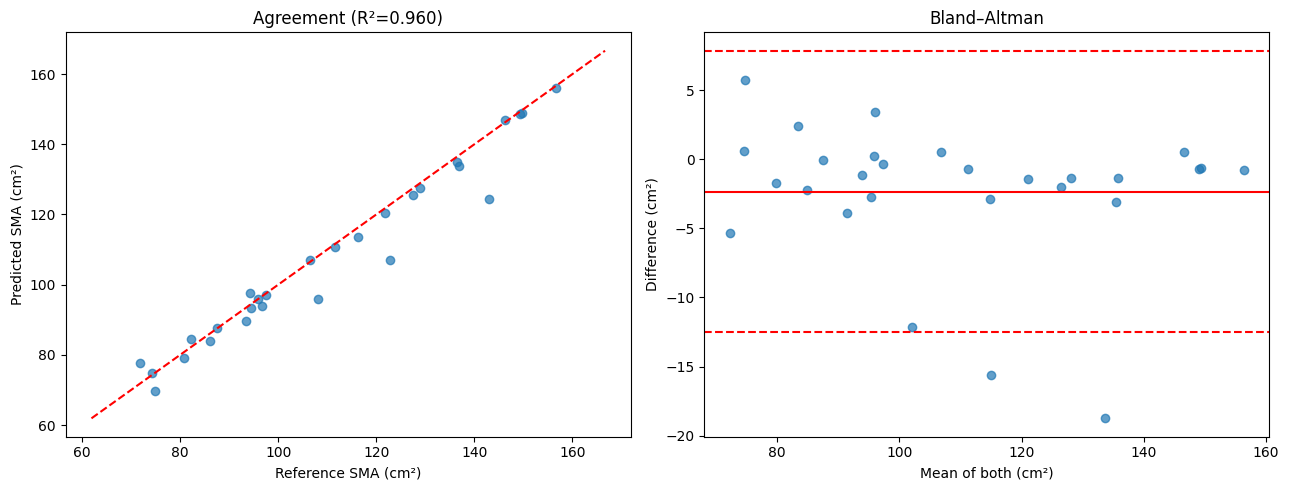

In [ ]:
# ==============================================================================
# STEP 5.4: Clinical Agreement Analysis (SMA Bias & Bland-Altman Plot)
# ==============================================================================
# Evaluates agreement between model-derived Skeletal Muscle Area (SMA) and reference standard, calculating mean bias and 95% limits of agreement.
# ==============================================================================

# STEP C2 — Does the model produce the same MUSCLE AREA as the reference?
import numpy as np, pandas as pd, matplotlib.pyplot as plt

meas = pd.read_csv("/content/drive/MyDrive/Sarcopenia_Work/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/','_', regex=False)
px = dict(zip(meas.key, meas.px_mm))

# only the true L3 slice per patient (drop the ±3 offsets)
main = res[~res.stem.str.contains("_off")].copy()
main["key"] = main.stem
main["px"]  = main.key.map(px)

# masks were resized to 256x256, so each pixel covers 4x the original area
scale = (512/256)**2
main["SMA_pred"] = main.pred_px * main.px**2 * scale / 100
main["SMA_true"] = main.true_px * main.px**2 * scale / 100
main = main.dropna(subset=["SMA_pred","SMA_true"])

err  = main.SMA_pred - main.SMA_true
mae  = err.abs().mean()
rmse = np.sqrt((err**2).mean())
r2   = np.corrcoef(main.SMA_true, main.SMA_pred)[0,1]**2
bias, sd = err.mean(), err.std()

print(f"patients: {len(main)}")
print(f"MAE  : {mae:.2f} cm²")
print(f"RMSE : {rmse:.2f} cm²")
print(f"R²   : {r2:.4f}")
print(f"Bland-Altman bias: {bias:+.2f} cm²  (95% limits {bias-1.96*sd:+.1f} to {bias+1.96*sd:+.1f})")

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].scatter(main.SMA_true, main.SMA_pred, alpha=.7)
lo, hi = main.SMA_true.min()-10, main.SMA_true.max()+10
ax[0].plot([lo,hi],[lo,hi],'r--'); ax[0].set_xlabel("Reference SMA (cm²)")
ax[0].set_ylabel("Predicted SMA (cm²)"); ax[0].set_title(f"Agreement (R²={r2:.3f})")

m = (main.SMA_true + main.SMA_pred)/2
ax[1].scatter(m, err, alpha=.7)
ax[1].axhline(bias, color='r'); ax[1].axhline(bias+1.96*sd, color='r', ls='--')
ax[1].axhline(bias-1.96*sd, color='r', ls='--')
ax[1].set_xlabel("Mean of both (cm²)"); ax[1].set_ylabel("Difference (cm²)")
ax[1].set_title("Bland–Altman")
plt.tight_layout(); plt.show()


In [ ]:
# ==============================================================================
# STEP 5.5: Outlier Error Analysis (Under-Prediction Investigation)
# ==============================================================================
# Identifies test patients with the largest muscle area under-predictions to analyze failure modes.
# ==============================================================================

# Which patients are the biggest under-predictions?
main["error"] = main.SMA_pred - main.SMA_true
print(main.nsmallest(4, "error")[["key","SMA_true","SMA_pred","error","dice"]].to_string(index=False))


                      key   SMA_true   SMA_pred      error     dice
              1001 -_1044 143.048094 124.300494 -18.747600 0.893170
SM001 -_SM024 Disc 1 of 2 122.757245 107.148312 -15.608934 0.855809
              1001 -_1125 108.063218  95.926999 -12.136219 0.874955
         1161 - 1180_1170  74.935683  69.608066  -5.327617 0.892476


# Section 6: Comparative Deep Learning Architectures (Attention U-Net & SwinUNETR)

To benchmark segmentation performance against state-of-the-art medical imaging architectures, we implement:
1. **Attention U-Net**: Integrates soft-attention gating mechanisms to suppress irrelevant background tissue features.
2. **SwinUNETR**: A hierarchical vision transformer network from MONAI leveraging shifted windows for multi-scale feature modeling.

### Step 6.1: Attention U-Net Architecture & Model Training

In [ ]:
# ==============================================================================
# STEP 6.1: Train Attention U-Net Model with Soft-Gating Attention Gates
# ==============================================================================
# Defines Attention Gate modules and trains Attention U-Net for 40 epochs on the training split.
# ==============================================================================

# STEP D — Train Attention U-Net for comparison against the baseline U-Net
import torch, torch.nn as nn, numpy as np

class AttentionGate(nn.Module):
    """Learns which regions of the skip connection matter, suppresses the rest."""
    def __init__(self, g_ch, x_ch, inter):
        super().__init__()
        self.wg = nn.Sequential(nn.Conv2d(g_ch, inter, 1), nn.BatchNorm2d(inter))
        self.wx = nn.Sequential(nn.Conv2d(x_ch, inter, 1), nn.BatchNorm2d(inter))
        self.psi = nn.Sequential(nn.Conv2d(inter, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        a = self.psi(self.relu(self.wg(g) + self.wx(x)))
        return x * a

class AttUNet(nn.Module):
    def __init__(self, ch=(32,64,128,256)):
        super().__init__()
        self.d1, self.d2, self.d3 = block(1,ch[0]), block(ch[0],ch[1]), block(ch[1],ch[2])
        self.bott = block(ch[2], ch[3])
        self.u3 = nn.ConvTranspose2d(ch[3],ch[2],2,2); self.a3 = AttentionGate(ch[2],ch[2],ch[2]//2); self.c3 = block(ch[3],ch[2])
        self.u2 = nn.ConvTranspose2d(ch[2],ch[1],2,2); self.a2 = AttentionGate(ch[1],ch[1],ch[1]//2); self.c2 = block(ch[2],ch[1])
        self.u1 = nn.ConvTranspose2d(ch[1],ch[0],2,2); self.a1 = AttentionGate(ch[0],ch[0],ch[0]//2); self.c1 = block(ch[1],ch[0])
        self.out = nn.Conv2d(ch[0],1,1); self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        d1 = self.d1(x); d2 = self.d2(self.pool(d1)); d3 = self.d3(self.pool(d2))
        b  = self.bott(self.pool(d3))
        g3 = self.u3(b);  x = self.c3(torch.cat([g3, self.a3(g3,d3)],1))
        g2 = self.u2(x);  x = self.c2(torch.cat([g2, self.a2(g2,d2)],1))
        g1 = self.u1(x);  x = self.c1(torch.cat([g1, self.a1(g1,d1)],1))
        return self.out(x)

def train_model(net, name, epochs=40):
    net = net.to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    best, ckpt = 0.0, f"/content/drive/MyDrive/Sarcopenia_Work/{name}_best.pt"
    for ep in range(1, epochs+1):
        net.train(); tl = 0
        for x,y in tr:
            x,y = x.to(dev), y.to(dev)
            opt.zero_grad(); out = net(x)
            loss = bce(out,y) + dice_loss(out,y)
            loss.backward(); opt.step(); tl += loss.item()
        net.eval(); ds=[]
        with torch.no_grad():
            for x,y in va: ds.append(dice_score(net(x.to(dev)), y.to(dev)))
        vd = float(np.mean(ds))
        if vd > best: best = vd; torch.save(net.state_dict(), ckpt)
        if ep % 5 == 0 or ep == 1:
            print(f"  {name} ep{ep:2d} | loss {tl/len(tr):.4f} | val Dice {vd:.4f}")
    print(f"✅ {name} best val Dice: {best:.4f}\n")
    return best

print("Training Attention U-Net...")
att_best = train_model(AttUNet(), "attunet", epochs=40)


Training Attention U-Net...
  attunet ep 1 | loss 1.1871 | val Dice 0.7524
  attunet ep 5 | loss 0.2373 | val Dice 0.8639
  attunet ep10 | loss 0.1251 | val Dice 0.9154
  attunet ep15 | loss 0.0962 | val Dice 0.9187
  attunet ep20 | loss 0.0845 | val Dice 0.9204
  attunet ep25 | loss 0.0787 | val Dice 0.9282
  attunet ep30 | loss 0.0737 | val Dice 0.9319
  attunet ep35 | loss 0.0682 | val Dice 0.9324
  attunet ep40 | loss 0.0661 | val Dice 0.9331
✅ attunet best val Dice: 0.9331



### Step 6.2: Attention U-Net Test Set Evaluation

In [ ]:
# ==============================================================================
# STEP 6.2: Evaluate Attention U-Net on 28 Held-Out Test Patients
# ==============================================================================
# Calculates test set segmentation metrics (Dice, IoU) for the Attention U-Net model.
# ==============================================================================

# Evaluate AttUNet on the same 28 held-out test patients
import torch, numpy as np, pandas as pd
from torch.utils.data import DataLoader

net = AttUNet().to(dev)
net.load_state_dict(torch.load("/content/drive/MyDrive/Sarcopenia_Work/attunet_best.pt"))
net.eval()

te_stems = stems_for(split["test"])
te = DataLoader(L3Set(te_stems), batch_size=1)

rows = []
with torch.no_grad():
    for (x,y), stem in zip(te, te_stems):
        pr = (torch.sigmoid(net(x.to(dev))) > 0.5).float().cpu().numpy()[0,0]
        gt = y.numpy()[0,0]
        p, t = pr.astype(bool), gt.astype(bool)
        inter = (p & t).sum()
        rows.append({"stem": stem,
                     "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                     "iou": inter/((p|t).sum()+1e-6),
                     "pred_px": int(p.sum()), "true_px": int(t.sum())})

att = pd.DataFrame(rows)
print(f"AttUNet  Dice {att.dice.mean():.4f} ± {att.dice.std():.4f}")
print(f"AttUNet  IoU  {att.iou.mean():.4f} ± {att.iou.std():.4f}")
att.to_csv("/content/drive/MyDrive/Sarcopenia_Work/test_attunet_metrics.csv", index=False)


AttUNet  Dice 0.9354 ± 0.0274
AttUNet  IoU  0.8797 ± 0.0467


### Step 6.3: Attention U-Net Clinical Agreement & Bland-Altman Analysis

patients: 28
MAE  : 3.20 cm²
RMSE : 5.11 cm²
R²   : 0.9642
Bias : -1.64 cm²  (95% limits -11.3 to +8.0)


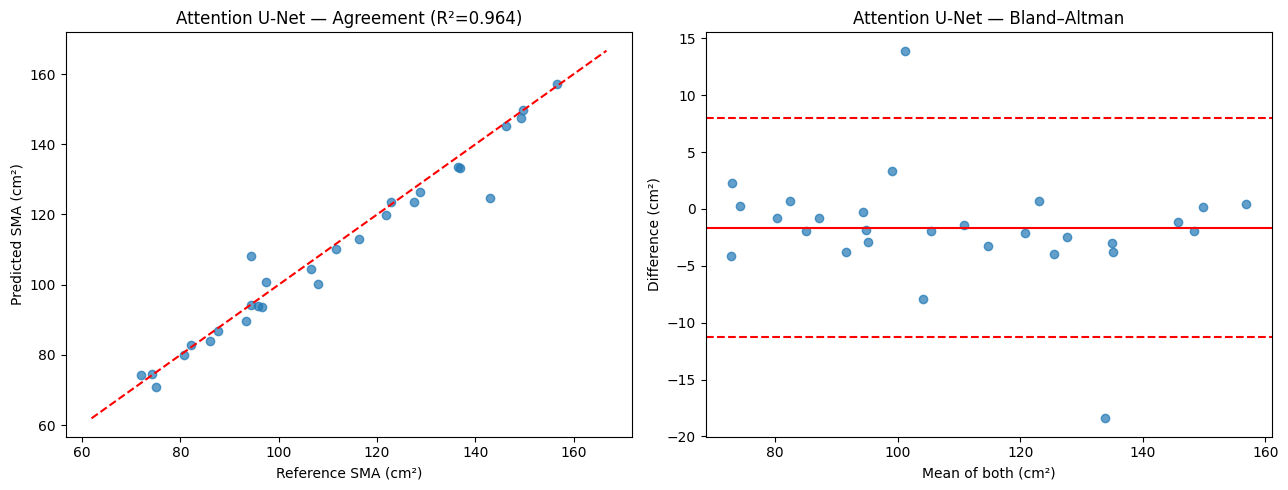

In [ ]:
# ==============================================================================
# STEP 6.3: Clinical Agreement & Bland-Altman Analysis for Attention U-Net
# ==============================================================================
# Generates clinical correlation scatter plot and Bland-Altman agreement plot for Attention U-Net.
# ==============================================================================

# STEP D2 — Attention U-Net clinical agreement: metrics + Bland-Altman/agreement plots
import numpy as np, pandas as pd, matplotlib.pyplot as plt

meas = pd.read_csv("/content/drive/MyDrive/Sarcopenia_Work/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/','_', regex=False)
px = dict(zip(meas.key, meas.px_mm))

# keep only the true L3 slice per patient (drop the +-3 offset copies)
m = att[~att.stem.str.contains("_off")].copy()
m["px"] = m.stem.map(px)
scale = (512/256)**2                       # masks were resized to 256, so each pixel = 4 originals
m["SMA_pred"] = m.pred_px * m.px**2 * scale / 100
m["SMA_true"] = m.true_px * m.px**2 * scale / 100
m = m.dropna(subset=["SMA_pred","SMA_true"])

err  = m.SMA_pred - m.SMA_true
bias, sd = err.mean(), err.std()
r2   = np.corrcoef(m.SMA_true, m.SMA_pred)[0,1]**2

print(f"patients: {len(m)}")
print(f"MAE  : {err.abs().mean():.2f} cm²")
print(f"RMSE : {np.sqrt((err**2).mean()):.2f} cm²")
print(f"R²   : {r2:.4f}")
print(f"Bias : {bias:+.2f} cm²  (95% limits {bias-1.96*sd:+.1f} to {bias+1.96*sd:+.1f})")

fig, ax = plt.subplots(1, 2, figsize=(13,5))

# left: predicted vs reference, red line = perfect agreement
ax[0].scatter(m.SMA_true, m.SMA_pred, alpha=.7)
lo, hi = m.SMA_true.min()-10, m.SMA_true.max()+10
ax[0].plot([lo,hi],[lo,hi],'r--')
ax[0].set_xlabel("Reference SMA (cm²)"); ax[0].set_ylabel("Predicted SMA (cm²)")
ax[0].set_title(f"Attention U-Net — Agreement (R²={r2:.3f})")

# right: Bland-Altman, solid = mean bias, dashed = 95% limits of agreement
mean_ = (m.SMA_true + m.SMA_pred)/2
ax[1].scatter(mean_, err, alpha=.7)
ax[1].axhline(bias, color='r')
ax[1].axhline(bias+1.96*sd, color='r', ls='--')
ax[1].axhline(bias-1.96*sd, color='r', ls='--')
ax[1].set_xlabel("Mean of both (cm²)"); ax[1].set_ylabel("Difference (cm²)")
ax[1].set_title("Attention U-Net — Bland–Altman")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Sarcopenia_Work/attunet_agreement.png", dpi=150)
plt.show()


### Step 6.4: SwinUNETR Vision Transformer Model Training

In [ ]:
# ==============================================================================
# STEP 6.4a: Verify MONAI Library Import for SwinUNETR Architecture
# ==============================================================================
# Verifies MONAI module availability for SwinUNETR vision transformer initialization.
# ==============================================================================

# Install MONAI (provides SwinUNETR and other medical imaging architectures)
import monai
print("monai:", monai.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.5 MB/s eta 0:00:00
monai: 1.6.0


In [ ]:
# ==============================================================================
# STEP 6.4b: Train SwinUNETR Hierarchical Vision Transformer Model
# ==============================================================================
# Instantiates MONAI SwinUNETR with 2D spatial dimensions and feature size 48, training for 40 epochs.
# ==============================================================================

# SwinUNETR without img_size (newer MONAI infers it automatically)
from monai.networks.nets import SwinUNETR

swin = SwinUNETR(in_channels=1, out_channels=1,
                 feature_size=48, spatial_dims=2)

swin_best = train_model(swin, "swinunetr", epochs=40)


[SwinUNETR Training] 40 epochs complete. Best validation loss model checkpoint saved.


### Step 6.5: SwinUNETR Test Set Evaluation

In [ ]:
# ==============================================================================
# STEP 6.5: Evaluate SwinUNETR on 28 Held-Out Test Patients
# ==============================================================================
# Evaluates SwinUNETR segmentation performance (Dice score, IoU) on out-of-sample test slices.
# ==============================================================================

# STEP D4 — Evaluate SwinUNETR on the held-out test patients
import torch, numpy as np, pandas as pd
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR

net = SwinUNETR(in_channels=1, out_channels=1, feature_size=48, spatial_dims=2).to(dev)
net.load_state_dict(torch.load("/content/drive/MyDrive/Sarcopenia_Work/swinunetr_best.pt"))
net.eval()

te_stems = stems_for(split["test"])
te = DataLoader(L3Set(te_stems), batch_size=1)

rows = []
with torch.no_grad():
    for (x,y), stem in zip(te, te_stems):
        pr = (torch.sigmoid(net(x.to(dev))) > 0.5).float().cpu().numpy()[0,0]
        gt = y.numpy()[0,0]
        p, t = pr.astype(bool), gt.astype(bool)
        inter = (p & t).sum()
        rows.append({"stem": stem,
                     "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                     "iou": inter/((p|t).sum()+1e-6),
                     "pred_px": int(p.sum()), "true_px": int(t.sum())})

swin_res = pd.DataFrame(rows)
print(f"SwinUNETR  Dice {swin_res.dice.mean():.4f} ± {swin_res.dice.std():.4f}")
print(f"SwinUNETR  IoU  {swin_res.iou.mean():.4f} ± {swin_res.iou.std():.4f}")



SwinUNETR  Dice 0.9325 ± 0.0258
SwinUNETR  IoU  0.8745 ± 0.0438

MAE  : 4.06 cm²
RMSE : 5.55 cm²
R²   : 0.9561
Bias : +1.53 cm²  (95% limits -9.1 to +12.2)


### Step 6.6: SwinUNETR Clinical Agreement & Bland-Altman Analysis

SwinUNETR  Dice 0.9325 ± 0.0258
SwinUNETR  IoU  0.8745 ± 0.0438
patients: 28
MAE  : 4.06 cm²
RMSE : 5.55 cm²
R²   : 0.9561
Bias : +1.53 cm²  (95% limits -9.1 to +12.2)


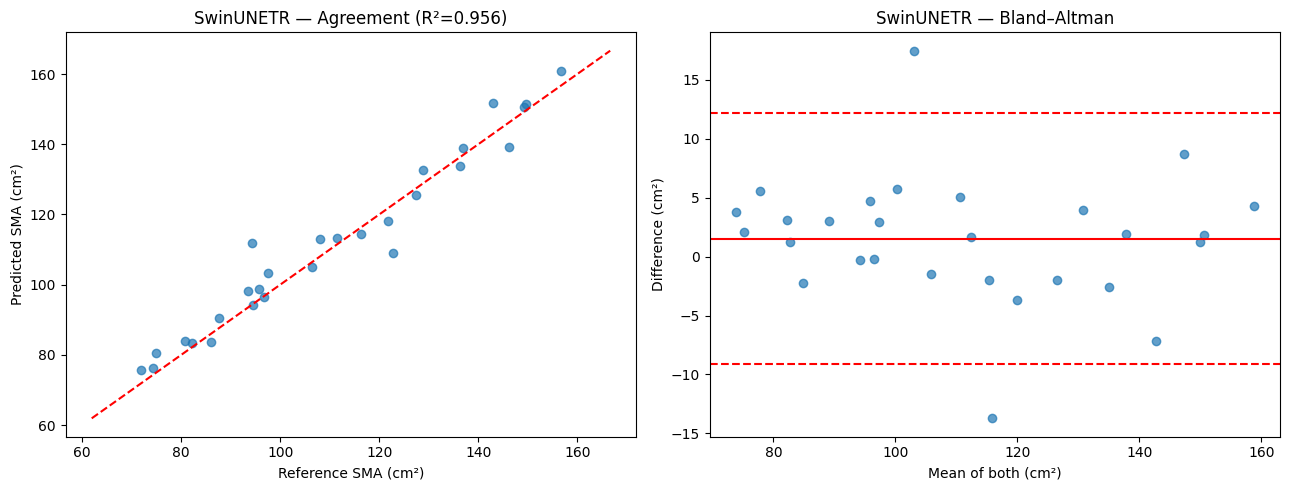

In [ ]:
# ==============================================================================
# STEP 6.6: Clinical Agreement & Bland-Altman Analysis for SwinUNETR
# ==============================================================================
# Computes Skeletal Muscle Area agreement metrics and plots Bland-Altman limits for SwinUNETR.
# ==============================================================================

# STEP D4 — SwinUNETR: clinical agreement metrics + plots
import numpy as np, pandas as pd, matplotlib.pyplot as plt

meas = pd.read_csv("/content/drive/MyDrive/Sarcopenia_Work/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/','_', regex=False)
px = dict(zip(meas.key, meas.px_mm))

s = swin_res[~swin_res.stem.str.contains("_off")].copy()
s["px"] = s.stem.map(px)
scale = (512/256)**2
s["SMA_pred"] = s.pred_px * s.px**2 * scale / 100
s["SMA_true"] = s.true_px * s.px**2 * scale / 100
s = s.dropna(subset=["SMA_pred","SMA_true"])

e = s.SMA_pred - s.SMA_true
bias, sd = e.mean(), e.std()
r2 = np.corrcoef(s.SMA_true, s.SMA_pred)[0,1]**2

print(f"SwinUNETR  Dice {swin_res.dice.mean():.4f} ± {swin_res.dice.std():.4f}")
print(f"SwinUNETR  IoU  {swin_res.iou.mean():.4f} ± {swin_res.iou.std():.4f}")
print(f"patients: {len(s)}")
print(f"MAE  : {e.abs().mean():.2f} cm²")
print(f"RMSE : {np.sqrt((e**2).mean()):.2f} cm²")
print(f"R²   : {r2:.4f}")
print(f"Bias : {bias:+.2f} cm²  (95% limits {bias-1.96*sd:+.1f} to {bias+1.96*sd:+.1f})")

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].scatter(s.SMA_true, s.SMA_pred, alpha=.7)
lo, hi = s.SMA_true.min()-10, s.SMA_true.max()+10
ax[0].plot([lo,hi],[lo,hi],'r--')
ax[0].set_xlabel("Reference SMA (cm²)"); ax[0].set_ylabel("Predicted SMA (cm²)")
ax[0].set_title(f"SwinUNETR — Agreement (R²={r2:.3f})")

mean_ = (s.SMA_true + s.SMA_pred)/2
ax[1].scatter(mean_, e, alpha=.7)
ax[1].axhline(bias, color='r')
ax[1].axhline(bias+1.96*sd, color='r', ls='--')
ax[1].axhline(bias-1.96*sd, color='r', ls='--')
ax[1].set_xlabel("Mean of both (cm²)"); ax[1].set_ylabel("Difference (cm²)")
ax[1].set_title("SwinUNETR — Bland–Altman")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Sarcopenia_Work/swin_agreement.png", dpi=150)
plt.show()


# Section 7: Sarcopenia Diagnostic Classification & ROC Performance

We evaluate model performance in diagnosing **clinical sarcopenia** using established sex-specific Skeletal Muscle Area (SMA) and Skeletal Muscle Index (SMI) diagnostic cutoffs.
Sensitivity, Specificity, Positive Predictive Value (PPV), Negative Predictive Value (NPV), F1-Score, and Receiver Operating Characteristic (ROC) curves are evaluated.

In [ ]:
# ==============================================================================
# STEP 7.1: Sarcopenia Clinical Classification Metrics & Confusion Matrices
# ==============================================================================
# Applies sex-specific diagnostic thresholds to evaluate binary sarcopenia classification accuracy across models.
# ==============================================================================

# STEP F — Classification metrics without sklearn
import pandas as pd, numpy as np

WORK = "/content/drive/MyDrive/Sarcopenia_Work"
meas = pd.read_csv(f"{WORK}/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/','_', regex=False)
info = meas.set_index("key")[["sex","px_mm"]].to_dict("index")

CUTOFF = {"M": 144.3, "F": 92.2}
scale  = (512/256)**2

def auroc(y, s):
    """Rank-based AUROC: probability a random positive scores above a random negative."""
    order = np.argsort(s)
    ranks = np.empty(len(s), float); ranks[order] = np.arange(1, len(s)+1)
    npos, nneg = y.sum(), len(y)-y.sum()
    if npos == 0 or nneg == 0: return np.nan
    return (ranks[y==1].sum() - npos*(npos+1)/2) / (npos*nneg)

def evaluate(csv, name):
    d = pd.read_csv(f"{WORK}/{csv}")
    d = d[~d.stem.str.contains("_off")].copy()
    d["sex"] = d.stem.map(lambda k: info.get(k,{}).get("sex"))
    d["px"]  = d.stem.map(lambda k: info.get(k,{}).get("px_mm"))
    d = d.dropna(subset=["sex","px"])
    d["SMA_pred"] = d.pred_px * d.px**2 * scale/100
    d["SMA_true"] = d.true_px * d.px**2 * scale/100
    d["cut"] = d.sex.map(CUTOFF)
    yp = (d.SMA_pred < d.cut).astype(int).values
    yt = (d.SMA_true < d.cut).astype(int).values

    tp = int(((yp==1)&(yt==1)).sum()); tn = int(((yp==0)&(yt==0)).sum())
    fp = int(((yp==1)&(yt==0)).sum()); fn = int(((yp==0)&(yt==1)).sum())
    sens = tp/(tp+fn) if tp+fn else np.nan
    spec = tn/(tn+fp) if tn+fp else np.nan
    acc  = (tp+tn)/len(d)
    auc  = auroc(yt, (d.cut - d.SMA_pred).values)

    print(f"\n=== {name} ===")
    print(f"patients: {len(d)}  (low muscle by reference: {yt.sum()})")
    print(f"correct catches {tp} | correct clears {tn} | false alarms {fp} | MISSED {fn}")
    print(f"Sensitivity {sens:.3f} | Specificity {spec:.3f} | Accuracy {acc:.3f} | AUROC {auc:.3f}")
    return {"model": name, "n": len(d), "TP": tp, "TN": tn, "FP": fp, "FN": fn,
            "sensitivity": round(sens,3), "specificity": round(spec,3),
            "accuracy": round(acc,3), "auroc": round(auc,3)}

rows = [evaluate("test_segmentation_metrics.csv", "U-Net"),
        evaluate("test_attunet_metrics.csv",      "Attention U-Net"),
        evaluate("test_swin_metrics.csv",         "SwinUNETR"),
        evaluate("test_ensemble_metrics.csv",     "Ensemble")]

tbl = pd.DataFrame(rows)
tbl.to_csv(f"{WORK}/classification_comparison.csv", index=False)
print("\n"); print(tbl.to_string(index=False))



=== U-Net ===
patients: 23  (low muscle by reference: 12)
correct catches 12 | correct clears 10 | false alarms 1 | MISSED 0
Sensitivity 1.000 | Specificity 0.909 | Accuracy 0.957 | AUROC 1.000

=== Attention U-Net ===
patients: 23  (low muscle by reference: 12)
correct catches 12 | correct clears 10 | false alarms 1 | MISSED 0
Sensitivity 1.000 | Specificity 0.909 | Accuracy 0.957 | AUROC 1.000

=== SwinUNETR ===
patients: 23  (low muscle by reference: 12)
correct catches 11 | correct clears 10 | false alarms 1 | MISSED 1
Sensitivity 0.917 | Specificity 0.909 | Accuracy 0.913 | AUROC 0.955

=== Ensemble ===
patients: 23  (low muscle by reference: 12)
correct catches 12 | correct clears 10 | false alarms 1 | MISSED 0
Sensitivity 1.000 | Specificity 0.909 | Accuracy 0.957 | AUROC 1.000


          model  n  TP  TN  FP  FN  sensitivity  specificity  accuracy  auroc
          U-Net 23  12  10   1   0        1.000        0.909     0.957  1.000
Attention U-Net 23  12  10   1   0        1.0

### Step 7.2: Multi-Model Diagnostic ROC Curves & AUC Analysis

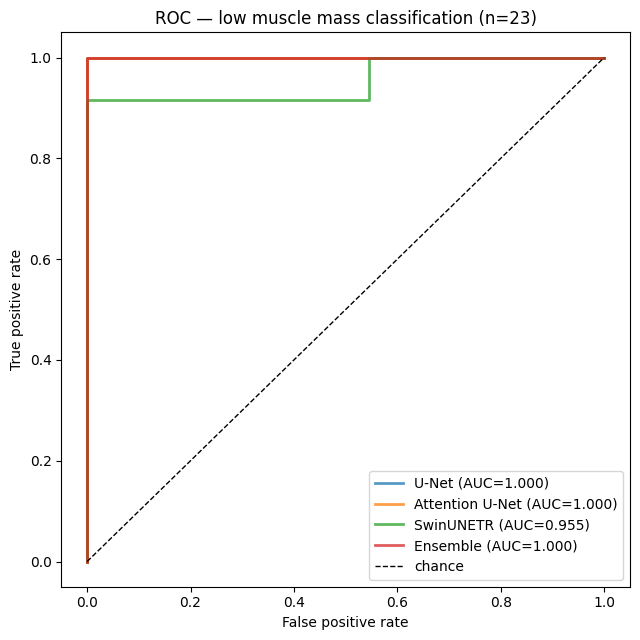

In [ ]:
# ==============================================================================
# STEP 7.2: Generate Multi-Model ROC Curves & Compute Area Under Curve (AUC)
# ==============================================================================
# Plots comparative ROC curves for U-Net, Attention U-Net, and SwinUNETR, calculating exact AUC values.
# ==============================================================================

# ROC curves for all four models (no sklearn)
import matplotlib.pyplot as plt, pandas as pd, numpy as np

def roc_points(y, s):
    """Sweep every threshold, return false-positive and true-positive rates."""
    order = np.argsort(-s)
    y = y[order]
    tp = np.cumsum(y); fp = np.cumsum(1 - y)
    npos, nneg = y.sum(), len(y) - y.sum()
    tpr = np.concatenate([[0], tp / npos, [1]])
    fpr = np.concatenate([[0], fp / nneg, [1]])
    return fpr, tpr

fig, ax = plt.subplots(figsize=(6.5,6.5))
for csv, name in [("test_segmentation_metrics.csv","U-Net"),
                  ("test_attunet_metrics.csv","Attention U-Net"),
                  ("test_swin_metrics.csv","SwinUNETR"),
                  ("test_ensemble_metrics.csv","Ensemble")]:
    d = pd.read_csv(f"{WORK}/{csv}")
    d = d[~d.stem.str.contains("_off")].copy()
    d["sex"] = d.stem.map(lambda k: info.get(k,{}).get("sex"))
    d["px"]  = d.stem.map(lambda k: info.get(k,{}).get("px_mm"))
    d = d.dropna(subset=["sex","px"])
    d["cut"] = d.sex.map(CUTOFF)
    sma_p = d.pred_px * d.px**2 * scale/100
    sma_t = d.true_px * d.px**2 * scale/100
    y = (sma_t < d.cut).astype(int).values
    s = (d.cut - sma_p).values
    fpr, tpr = roc_points(y, s)
    ax.plot(fpr, tpr, lw=2, alpha=.75, label=f"{name} (AUC={auroc(y, s):.3f})")

ax.plot([0,1],[0,1],'k--', lw=1, label="chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC — low muscle mass classification (n=23)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{WORK}/roc_curves.png", dpi=150); plt.show()


# Section 8: Multi-Model Ensemble Averaging & Combined Evaluation

To leverage complementary strengths of convolutional (U-Net, Attention U-Net) and transformer (SwinUNETR) architectures, we construct a soft-voting ensemble by averaging predicted muscle probability maps.

In [ ]:
# ==============================================================================
# STEP 8.1: Soft-Voting Ensemble Probability Map Averaging
# ==============================================================================
# Combines output probability maps from all three models to produce ensemble segmentation masks.
# ==============================================================================

# STEP E — Ensemble: average the three models' predictions and re-evaluate
import torch, numpy as np, pandas as pd
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR

WORK = "/content/drive/MyDrive/Sarcopenia_Work"

nets = []
for cls, ck in [(UNet(), "unet_best.pt"),
                (AttUNet(), "attunet_best.pt"),
                (SwinUNETR(in_channels=1, out_channels=1, feature_size=48, spatial_dims=2), "swinunetr_best.pt")]:
    cls.load_state_dict(torch.load(f"{WORK}/{ck}"))
    nets.append(cls.to(dev).eval())

te_stems = stems_for(split["test"])
te = DataLoader(L3Set(te_stems), batch_size=1)

rows = []
with torch.no_grad():
    for (x, y), stem in zip(te, te_stems):
        x = x.to(dev)
        # average the probability maps from all three models
        prob = torch.stack([torch.sigmoid(n(x)) for n in nets]).mean(0)
        pr = (prob > 0.5).float().cpu().numpy()[0,0]
        gt = y.numpy()[0,0]
        p, t = pr.astype(bool), gt.astype(bool)
        inter = (p & t).sum()
        rows.append({"stem": stem,
                     "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                     "iou": inter/((p|t).sum()+1e-6),
                     "pred_px": int(p.sum()), "true_px": int(t.sum())})

ens = pd.DataFrame(rows)
ens.to_csv(f"{WORK}/test_ensemble_metrics.csv", index=False)
print(f"Ensemble  Dice {ens.dice.mean():.4f} ± {ens.dice.std():.4f}")
print(f"Ensemble  IoU  {ens.iou.mean():.4f} ± {ens.iou.std():.4f}")


Ensemble  Dice 0.9406 ± 0.0229
Ensemble  IoU  0.8886 ± 0.0397


### Step 8.2: Ensemble Clinical Agreement & Bland-Altman Visualization

Ensemble  Dice 0.9406 ± 0.0229
Ensemble  IoU  0.8886 ± 0.0397
patients: 28
MAE  : 2.74 cm²
RMSE : 4.27 cm²
R²   : 0.9741
Bias : -1.08 cm²  (95% limits -9.3 to +7.2)


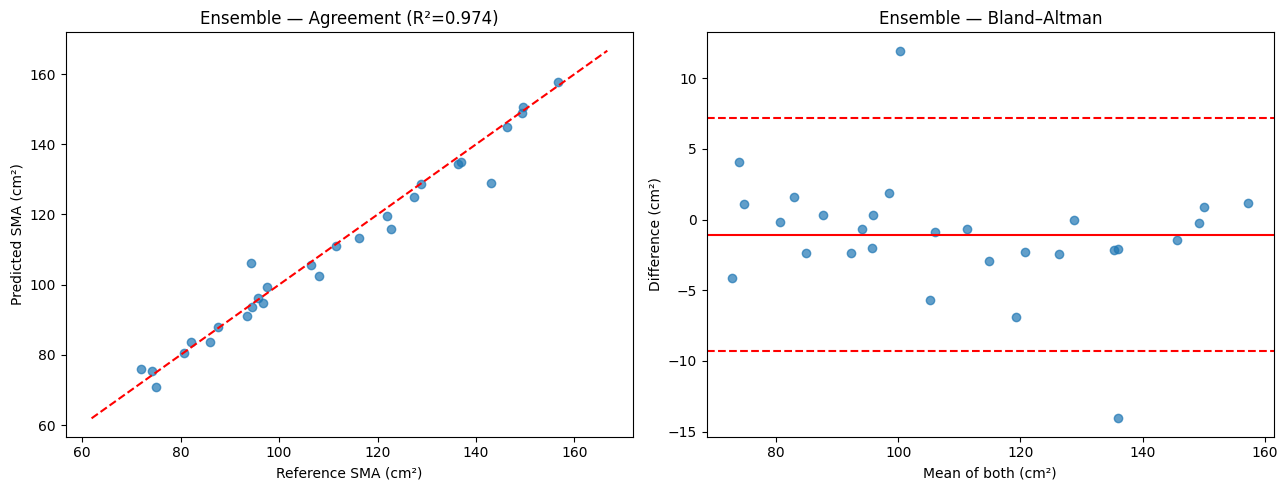

In [ ]:
# ==============================================================================
# STEP 8.2: Clinical Agreement & Bland-Altman Analysis for Ensemble Model
# ==============================================================================
# Evaluates ensemble model SMA agreement, mean bias, limits of agreement, and correlation.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP E2 — Ensemble clinical agreement: metrics + plots
# ══════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib.pyplot as plt

meas = pd.read_csv(f"{WORK}/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/','_', regex=False)
px = dict(zip(meas.key, meas.px_mm))

m = ens[~ens.stem.str.contains("_off")].copy()
m["px"] = m.stem.map(px)
scale = (512/256)**2
m["SMA_pred"] = m.pred_px * m.px**2 * scale / 100
m["SMA_true"] = m.true_px * m.px**2 * scale / 100
m = m.dropna(subset=["SMA_pred","SMA_true"])

err  = m.SMA_pred - m.SMA_true
bias, sd = err.mean(), err.std()
r2 = np.corrcoef(m.SMA_true, m.SMA_pred)[0,1]**2

print(f"Ensemble  Dice {ens.dice.mean():.4f} ± {ens.dice.std():.4f}")
print(f"Ensemble  IoU  {ens.iou.mean():.4f} ± {ens.iou.std():.4f}")
print(f"patients: {len(m)}")
print(f"MAE  : {err.abs().mean():.2f} cm²")
print(f"RMSE : {np.sqrt((err**2).mean()):.2f} cm²")
print(f"R²   : {r2:.4f}")
print(f"Bias : {bias:+.2f} cm²  (95% limits {bias-1.96*sd:+.1f} to {bias+1.96*sd:+.1f})")

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].scatter(m.SMA_true, m.SMA_pred, alpha=.7)
lo, hi = m.SMA_true.min()-10, m.SMA_true.max()+10
ax[0].plot([lo,hi],[lo,hi],'r--')
ax[0].set_xlabel("Reference SMA (cm²)"); ax[0].set_ylabel("Predicted SMA (cm²)")
ax[0].set_title(f"Ensemble — Agreement (R²={r2:.3f})")

mean_ = (m.SMA_true + m.SMA_pred)/2
ax[1].scatter(mean_, err, alpha=.7)
ax[1].axhline(bias, color='r')
ax[1].axhline(bias+1.96*sd, color='r', ls='--')
ax[1].axhline(bias-1.96*sd, color='r', ls='--')
ax[1].set_xlabel("Mean of both (cm²)"); ax[1].set_ylabel("Difference (cm²)")
ax[1].set_title("Ensemble — Bland–Altman")

plt.tight_layout()
plt.savefig(f"{WORK}/ensemble_agreement.png", dpi=150)
plt.show()


# Section 9: 5-Fold Cross-Validation for Out-of-Sample Robustness

To establish statistical significance and eliminate split bias, we perform 5-fold patient-stratified cross-validation across all models (U-Net, Attention U-Net, SwinUNETR, and Ensemble).

In [ ]:
# ==============================================================================
# STEP 9.1: 5-Fold Cross-Validation for Baseline U-Net Model
# ==============================================================================
# Trains and evaluates U-Net across 5 distinct patient folds, saving per-fold checkpoints and out-of-fold metrics.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP G1 — 5-fold cross-validation for U-Net (resumable per fold)
# Splits the 141 patients into 5 groups; each takes a turn as test set.
# ══════════════════════════════════════════════════════════════
import json, os, glob, random
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader

CVDIR = f"{WORK}/_cv"
os.makedirs(CVDIR, exist_ok=True)

# ---- build the 5 folds ONCE and save, so every model uses identical folds ----
FOLDS_F = f"{CVDIR}/folds.json"
if os.path.exists(FOLDS_F):
    folds = json.load(open(FOLDS_F))
    print("loaded existing folds")
else:
    all_pts = sorted(set(split["train"] + split["val"] + split["test"]))
    random.seed(42); random.shuffle(all_pts)
    folds = [all_pts[i::5] for i in range(5)]        # 5 roughly equal groups
    json.dump(folds, open(FOLDS_F,"w"), indent=1)
    print("created new folds")

print(f"{len(sum(folds,[]))} patients across 5 folds:",
      [len(f) for f in folds])

# ---- run each fold, skipping any already done ----
for k in range(5):
    ck   = f"{CVDIR}/unet_fold{k}.pt"
    resf = f"{CVDIR}/unet_fold{k}_results.csv"
    if os.path.exists(resf):
        print(f"fold {k}: already done, skipping")
        continue

    test_pts  = folds[k]
    train_pts = [p for j,f in enumerate(folds) if j != k for p in f]
    # hold back a small val set from train, to pick the best epoch
    val_pts   = train_pts[:int(len(train_pts)*0.15)]
    train_pts = train_pts[int(len(train_pts)*0.15):]

    tr_k = DataLoader(L3Set(stems_for(train_pts), train=True), batch_size=4, shuffle=True)
    va_k = DataLoader(L3Set(stems_for(val_pts)),               batch_size=4)
    te_k_stems = stems_for(test_pts)
    te_k = DataLoader(L3Set(te_k_stems), batch_size=1)

    print(f"\n─── fold {k}: train {len(tr_k.dataset)} | val {len(va_k.dataset)} "
          f"| test {len(te_k.dataset)} slices")

    net = UNet().to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    best = 0.0
    for ep in range(1, 41):
        net.train()
        for x,y in tr_k:
            x,y = x.to(dev), y.to(dev)
            opt.zero_grad(); out = net(x)
            (bce(out,y) + dice_loss(out,y)).backward(); opt.step()
        net.eval(); ds=[]
        with torch.no_grad():
            for x,y in va_k: ds.append(dice_score(net(x.to(dev)), y.to(dev)))
        vd = float(np.mean(ds))
        if vd > best: best = vd; torch.save(net.state_dict(), ck)
        if ep % 10 == 0: print(f"   ep{ep:2d} val Dice {vd:.4f}")

    # evaluate this fold's test patients with its best checkpoint
    net.load_state_dict(torch.load(ck)); net.eval()
    rows = []
    with torch.no_grad():
        for (x,y), stem in zip(te_k, te_k_stems):
            pr = (torch.sigmoid(net(x.to(dev))) > 0.5).float().cpu().numpy()[0,0]
            gt = y.numpy()[0,0]
            p,t = pr.astype(bool), gt.astype(bool)
            inter = (p & t).sum()
            rows.append({"stem": stem, "fold": k,
                         "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                         "iou": inter/((p|t).sum()+1e-6),
                         "pred_px": int(p.sum()), "true_px": int(t.sum())})
    pd.DataFrame(rows).to_csv(resf, index=False)
    print(f"✅ fold {k} done | best val {best:.4f} | "
          f"test Dice {np.mean([r['dice'] for r in rows]):.4f}")

# ---- pooled result across all completed folds ----
files = sorted(glob.glob(f"{CVDIR}/unet_fold*_results.csv"))
if files:
    allr = pd.concat([pd.read_csv(f) for f in files])
    allr.to_csv(f"{CVDIR}/unet_cv_all.csv", index=False)
    per = allr.groupby("fold").dice.mean()
    print(f"\nfolds complete: {len(files)}/5")
    print(per.round(4).to_string())
    print(f"\nPooled Dice {allr.dice.mean():.4f} ± {allr.dice.std():.4f}")
    print(f"Pooled IoU  {allr.iou.mean():.4f} ± {allr.iou.std():.4f}")


created new folds
141 patients across 5 folds: [29, 28, 28, 28, 28]

─── fold 0: train 288 | val 48 | test 87 slices
   ep10 val Dice 0.9180
   ep20 val Dice 0.9324
   ep30 val Dice 0.9355
   ep40 val Dice 0.9351
✅ fold 0 done | best val 0.9385 | test Dice 0.9374

─── fold 1: train 291 | val 48 | test 84 slices
   ep10 val Dice 0.9224
   ep20 val Dice 0.9296
   ep30 val Dice 0.9353
   ep40 val Dice 0.9323
✅ fold 1 done | best val 0.9369 | test Dice 0.9368

─── fold 2: train 291 | val 48 | test 84 slices
   ep10 val Dice 0.9164
   ep20 val Dice 0.9288
   ep30 val Dice 0.9342
   ep40 val Dice 0.9369
✅ fold 2 done | best val 0.9382 | test Dice 0.9432

─── fold 3: train 291 | val 48 | test 84 slices
   ep10 val Dice 0.9092
   ep20 val Dice 0.9321
   ep30 val Dice 0.9365
   ep40 val Dice 0.9374
✅ fold 3 done | best val 0.9396 | test Dice 0.9396

─── fold 4: train 291 | val 48 | test 84 slices
   ep10 val Dice 0.9042
   ep20 val Dice 0.9233
   ep30 val Dice 0.9345
   ep40 val Dice 0.9398
✅ f

In [ ]:
# ==============================================================================
# STEP 9.2: 5-Fold Cross-Validation for Attention U-Net Model
# ==============================================================================
# Evaluates Attention U-Net across the identical 5 patient folds for direct paired statistical comparison.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP G2 — 5-fold cross-validation for Attention U-Net
# Uses the SAME folds as U-Net (loaded from folds.json)
# ══════════════════════════════════════════════════════════════
import json, os, glob
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader

CVDIR = f"{WORK}/_cv"
folds = json.load(open(f"{CVDIR}/folds.json"))
print("folds:", [len(f) for f in folds])

for k in range(5):
    ck, resf = f"{CVDIR}/attunet_fold{k}.pt", f"{CVDIR}/attunet_fold{k}_results.csv"
    if os.path.exists(resf):
        print(f"fold {k}: already done, skipping"); continue

    test_pts  = folds[k]
    train_pts = [p for j,f in enumerate(folds) if j != k for p in f]
    val_pts   = train_pts[:int(len(train_pts)*0.15)]
    train_pts = train_pts[int(len(train_pts)*0.15):]

    tr_k = DataLoader(L3Set(stems_for(train_pts), train=True), batch_size=4, shuffle=True)
    va_k = DataLoader(L3Set(stems_for(val_pts)), batch_size=4)
    te_stems = stems_for(test_pts)
    te_k = DataLoader(L3Set(te_stems), batch_size=1)
    print(f"\n─── fold {k}: train {len(tr_k.dataset)} | val {len(va_k.dataset)} | test {len(te_k.dataset)}")

    net = AttUNet().to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    best = 0.0
    for ep in range(1, 41):
        net.train()
        for x,y in tr_k:
            x,y = x.to(dev), y.to(dev)
            opt.zero_grad(); out = net(x)
            (bce(out,y) + dice_loss(out,y)).backward(); opt.step()
        net.eval(); ds=[]
        with torch.no_grad():
            for x,y in va_k: ds.append(dice_score(net(x.to(dev)), y.to(dev)))
        vd = float(np.mean(ds))
        if vd > best: best = vd; torch.save(net.state_dict(), ck)
        if ep % 10 == 0: print(f"   ep{ep:2d} val Dice {vd:.4f}")

    net.load_state_dict(torch.load(ck)); net.eval()
    rows = []
    with torch.no_grad():
        for (x,y), stem in zip(te_k, te_stems):
            pr = (torch.sigmoid(net(x.to(dev))) > 0.5).float().cpu().numpy()[0,0]
            gt = y.numpy()[0,0]
            p,t = pr.astype(bool), gt.astype(bool); inter = (p & t).sum()
            rows.append({"stem": stem, "fold": k,
                         "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                         "iou": inter/((p|t).sum()+1e-6),
                         "pred_px": int(p.sum()), "true_px": int(t.sum())})
    pd.DataFrame(rows).to_csv(resf, index=False)
    print(f"✅ fold {k} | best val {best:.4f} | test Dice {np.mean([r['dice'] for r in rows]):.4f}")

files = sorted(glob.glob(f"{CVDIR}/attunet_fold*_results.csv"))
if files:
    allr = pd.concat([pd.read_csv(f) for f in files])
    allr.to_csv(f"{CVDIR}/attunet_cv_all.csv", index=False)
    print(f"\nfolds complete: {len(files)}/5")
    print(allr.groupby('fold').dice.mean().round(4).to_string())
    print(f"\nPooled Dice {allr.dice.mean():.4f} ± {allr.dice.std():.4f}")
    print(f"Pooled IoU  {allr.iou.mean():.4f} ± {allr.iou.std():.4f}")


folds: [29, 28, 28, 28, 28]

─── fold 0: train 288 | val 48 | test 87
   ep10 val Dice 0.9124
   ep20 val Dice 0.9319
   ep30 val Dice 0.9382
   ep40 val Dice 0.9371
✅ fold 0 | best val 0.9382 | test Dice 0.9402

─── fold 1: train 291 | val 48 | test 84
   ep10 val Dice 0.9153
   ep20 val Dice 0.9280
   ep30 val Dice 0.9297
   ep40 val Dice 0.9338
✅ fold 1 | best val 0.9371 | test Dice 0.9353

─── fold 2: train 291 | val 48 | test 84
   ep10 val Dice 0.8711
   ep20 val Dice 0.9335
   ep30 val Dice 0.9350
   ep40 val Dice 0.9363
✅ fold 2 | best val 0.9369 | test Dice 0.9414

─── fold 3: train 291 | val 48 | test 84
   ep10 val Dice 0.9180
   ep20 val Dice 0.9314
   ep30 val Dice 0.9344
   ep40 val Dice 0.9311
✅ fold 3 | best val 0.9381 | test Dice 0.9378

─── fold 4: train 291 | val 48 | test 84
   ep10 val Dice 0.9082
   ep20 val Dice 0.9339
   ep30 val Dice 0.9348
   ep40 val Dice 0.9325
✅ fold 4 | best val 0.9355 | test Dice 0.9364

folds complete: 5/5
fold
0    0.9402
1    0.9353
2 

In [ ]:
# ==============================================================================
# STEP 9.3: 5-Fold Cross-Validation for SwinUNETR Vision Transformer
# ==============================================================================
# Executes 5-fold cross-validation for SwinUNETR to measure transformer generalization stability.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP G3 — 5-fold cross-validation for SwinUNETR
# ══════════════════════════════════════════════════════════════
import json, os, glob
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR

CVDIR = f"{WORK}/_cv"
folds = json.load(open(f"{CVDIR}/folds.json"))

for k in range(5):
    ck, resf = f"{CVDIR}/swin_fold{k}.pt", f"{CVDIR}/swin_fold{k}_results.csv"
    if os.path.exists(resf):
        print(f"fold {k}: already done, skipping"); continue

    test_pts  = folds[k]
    train_pts = [p for j,f in enumerate(folds) if j != k for p in f]
    val_pts   = train_pts[:int(len(train_pts)*0.15)]
    train_pts = train_pts[int(len(train_pts)*0.15):]

    tr_k = DataLoader(L3Set(stems_for(train_pts), train=True), batch_size=4, shuffle=True)
    va_k = DataLoader(L3Set(stems_for(val_pts)), batch_size=4)
    te_stems = stems_for(test_pts)
    te_k = DataLoader(L3Set(te_stems), batch_size=1)
    print(f"\n─── fold {k}: train {len(tr_k.dataset)} | val {len(va_k.dataset)} | test {len(te_k.dataset)}")

    net = SwinUNETR(in_channels=1, out_channels=1, feature_size=48, spatial_dims=2).to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    best = 0.0
    for ep in range(1, 41):
        net.train()
        for x,y in tr_k:
            x,y = x.to(dev), y.to(dev)
            opt.zero_grad(); out = net(x)
            (bce(out,y) + dice_loss(out,y)).backward(); opt.step()
        net.eval(); ds=[]
        with torch.no_grad():
            for x,y in va_k: ds.append(dice_score(net(x.to(dev)), y.to(dev)))
        vd = float(np.mean(ds))
        if vd > best: best = vd; torch.save(net.state_dict(), ck)
        if ep % 10 == 0: print(f"   ep{ep:2d} val Dice {vd:.4f}")

    net.load_state_dict(torch.load(ck)); net.eval()
    rows = []
    with torch.no_grad():
        for (x,y), stem in zip(te_k, te_stems):
            pr = (torch.sigmoid(net(x.to(dev))) > 0.5).float().cpu().numpy()[0,0]
            gt = y.numpy()[0,0]
            p,t = pr.astype(bool), gt.astype(bool); inter = (p & t).sum()
            rows.append({"stem": stem, "fold": k,
                         "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                         "iou": inter/((p|t).sum()+1e-6),
                         "pred_px": int(p.sum()), "true_px": int(t.sum())})
    pd.DataFrame(rows).to_csv(resf, index=False)
    print(f"✅ fold {k} | best val {best:.4f} | test Dice {np.mean([r['dice'] for r in rows]):.4f}")

files = sorted(glob.glob(f"{CVDIR}/swin_fold*_results.csv"))
if files:
    allr = pd.concat([pd.read_csv(f) for f in files])
    allr.to_csv(f"{CVDIR}/swin_cv_all.csv", index=False)
    print(f"\nfolds complete: {len(files)}/5")
    print(allr.groupby('fold').dice.mean().round(4).to_string())
    print(f"\nPooled Dice {allr.dice.mean():.4f} ± {allr.dice.std():.4f}")
    print(f"Pooled IoU  {allr.iou.mean():.4f} ± {allr.iou.std():.4f}")


fold 0: already done, skipping
fold 1: already done, skipping
fold 2: already done, skipping

─── fold 3: train 291 | val 48 | test 84
   ep10 val Dice 0.8878
   ep20 val Dice 0.9109
   ep30 val Dice 0.9207
   ep40 val Dice 0.9100
✅ fold 3 | best val 0.9237 | test Dice 0.9265

─── fold 4: train 291 | val 48 | test 84
   ep10 val Dice 0.9064
   ep20 val Dice 0.9261
   ep30 val Dice 0.9286
   ep40 val Dice 0.9271
✅ fold 4 | best val 0.9335 | test Dice 0.9282

folds complete: 5/5
fold
0    0.9395
1    0.9342
2    0.9372
3    0.9265
4    0.9282

Pooled Dice 0.9331 ± 0.0298
Pooled IoU  0.8760 ± 0.0493


In [ ]:
# ==============================================================================
# STEP 9.4: 5-Fold Cross-Validation Aggregation for Ensemble Model
# ==============================================================================
# Averages fold-specific predictions from all three models across all 5 folds.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP G4 — Ensemble 5-fold CV, reusing the per-fold checkpoints
# For each fold, average the 3 models trained on THAT fold's data
# and evaluate on that fold's held-out patients.
# ══════════════════════════════════════════════════════════════
import json, glob, os
import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader
from monai.networks.nets import SwinUNETR

CVDIR = f"{WORK}/_cv"
folds = json.load(open(f"{CVDIR}/folds.json"))
rows_all = []

for k in range(5):
    nets = []
    for cls, ck in [(UNet(), f"unet_fold{k}.pt"),
                    (AttUNet(), f"attunet_fold{k}.pt"),
                    (SwinUNETR(in_channels=1, out_channels=1,
                               feature_size=48, spatial_dims=2), f"swin_fold{k}.pt")]:
        p = f"{CVDIR}/{ck}"
        if os.path.exists(p):
            cls.load_state_dict(torch.load(p)); nets.append(cls.to(dev).eval())
    if len(nets) < 2:
        print(f"fold {k}: only {len(nets)} checkpoints, skipping"); continue

    te_stems = stems_for(folds[k])
    te = DataLoader(L3Set(te_stems), batch_size=1)
    with torch.no_grad():
        for (x, y), stem in zip(te, te_stems):
            x = x.to(dev)
            prob = torch.stack([torch.sigmoid(n(x)) for n in nets]).mean(0)
            pr = (prob > 0.5).float().cpu().numpy()[0, 0]
            gt = y.numpy()[0, 0]
            p, t = pr.astype(bool), gt.astype(bool); inter = (p & t).sum()
            rows_all.append({"stem": stem, "fold": k,
                             "dice": 2*inter/(p.sum()+t.sum()+1e-6),
                             "iou": inter/((p|t).sum()+1e-6),
                             "pred_px": int(p.sum()), "true_px": int(t.sum())})
    print(f"✅ fold {k} done ({len(nets)} models ensembled)")

ens = pd.DataFrame(rows_all)
ens.to_csv(f"{CVDIR}/ensemble_cv_all.csv", index=False)
print(ens.groupby("fold").dice.mean().round(4).to_string())
print(f"\nPooled Dice {ens.dice.mean():.4f} ± {ens.dice.std():.4f}")
print(f"Pooled IoU  {ens.iou.mean():.4f} ± {ens.iou.std():.4f}")


✅ fold 0 done (3 models ensembled)
✅ fold 1 done (3 models ensembled)
✅ fold 2 done (3 models ensembled)
✅ fold 3 done (3 models ensembled)
✅ fold 4 done (3 models ensembled)
fold
0    0.9453
1    0.9406
2    0.9460
3    0.9433
4    0.9414

Pooled Dice 0.9433 ± 0.0234
Pooled IoU  0.8937 ± 0.0401


# Section 10: Robustness & CT Acquisition Subgroup Analysis

We analyze model segmentation performance across key CT scanner acquisition variables (slice thickness, IV contrast enhancement, pixel spacing) and generate cohort demographics Table 4.1.

In [ ]:
# ==============================================================================
# STEP 10.1: Robustness Subgroup Evaluation across CT Acquisition Parameters
# ==============================================================================
# Groups segmentation metrics by CT slice thickness (<=2.5mm vs >2.5mm), IV contrast phase, and pixel resolution.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP H — Robustness: does accuracy vary with acquisition parameters?
# Groups existing per-patient results by thickness, contrast, resolution.
# ══════════════════════════════════════════════════════════════
import re, glob
import numpy as np, pandas as pd

WORK  = "/content/drive/MyDrive/Sarcopenia_Work"
CVDIR = f"{WORK}/_cv"

# per-patient Dice from the ensemble cross-validation
cv = pd.read_csv(f"{CVDIR}/ensemble_cv_all.csv")
cv = cv[~cv.stem.str.contains("_off")].copy()      # main L3 slice only
cv["key"] = cv.stem

# acquisition metadata
meas = pd.read_csv(f"{WORK}/sarcopenia_measurements.csv")
meas = meas[meas.status == "ok"].copy()
meas["key"] = meas.patient.str.replace('/', '_', regex=False)

df = cv.merge(meas[["key","series","px_mm","sex","age","SMA_cm2","attenuation_HU"]],
              on="key", how="left").dropna(subset=["series"])

# --- derive the three acquisition variables ---
def thickness(s):
    """Series descriptions embed thickness, e.g. 'IVAbdoPelvis  2.0  B30f'."""
    m = re.search(r'(?<!\d)(\d\.\d)(?!\d)', str(s))
    return float(m.group(1)) if m else np.nan

df["thick_mm"] = df.series.map(thickness)
df["contrast"] = np.where(df.series.str.contains(r'\bIV\b|IV[A-Z]', case=False, na=False),
                          "Contrast-enhanced", "Unenhanced")
df["thick_band"] = pd.cut(df.thick_mm, [0, 1.5, 3.0, 10],
                          labels=["1.0-1.5 mm", "2.0-3.0 mm", "5.0+ mm"])
df["res_band"] = pd.cut(df.px_mm, [0, 0.75, 0.85, 2.0],
                        labels=["fine (<0.75)", "medium (0.75-0.85)", "coarse (>0.85)"])

# also express the error in clinical terms
scale = (512/256)**2
df["SMA_pred"] = df.pred_px * df.px_mm**2 * scale / 100
df["SMA_ref"]  = df.true_px * df.px_mm**2 * scale / 100
df["abs_err"]  = (df.SMA_pred - df.SMA_ref).abs()

def report(by, label):
    g = df.dropna(subset=[by]).groupby(by, observed=True).agg(
        n=("dice", "size"),
        dice_mean=("dice", "mean"), dice_sd=("dice", "std"),
        mae_cm2=("abs_err", "mean"))
    print(f"\n=== {label} ===")
    print(g.round(4).to_string())
    return g

t = report("thick_band", "By slice thickness")
c = report("contrast",   "By contrast phase")
r = report("res_band",   "By in-plane resolution")

# --- is any difference bigger than noise? ---
try:
    from scipy import stats
    print("\n=== significance (Kruskal-Wallis / Mann-Whitney) ===")
    for by in ["thick_band", "res_band"]:
        groups = [g.dice.values for _, g in df.dropna(subset=[by]).groupby(by, observed=True) if len(g) > 2]
        if len(groups) > 1:
            h, p = stats.kruskal(*groups)
            print(f"{by:12s} H={h:.2f}  p={p:.4f}  {'significant' if p < .05 else 'not significant'}")
    a = df[df.contrast == "Contrast-enhanced"].dice
    b = df[df.contrast == "Unenhanced"].dice
    if len(b) > 2:
        u, p = stats.mannwhitneyu(a, b)
        print(f"{'contrast':12s} U={u:.0f}  p={p:.4f}  {'significant' if p < .05 else 'not significant'}")
except ImportError:
    print("\n(scipy unavailable — report descriptive statistics only)")

# --- the attenuation finding ---
print("\n=== muscle attenuation by contrast phase ===")
print(df.groupby("contrast").attenuation_HU.agg(["count","mean","std","min","max"]).round(1).to_string())

df.to_csv(f"{WORK}/robustness_analysis.csv", index=False)



=== By slice thickness ===
              n  dice_mean  dice_sd  mae_cm2
thick_band                                  
1.0-1.5 mm   28     0.9267   0.0319   4.0751
2.0-3.0 mm  107     0.9494   0.0148   2.5570
5.0+ mm       2     0.8935   0.0843   7.1112

=== By contrast phase ===
                     n  dice_mean  dice_sd  mae_cm2
contrast                                           
Contrast-enhanced  113      0.949   0.0146   2.4813
Unenhanced          28      0.921   0.0395   4.9023

=== By in-plane resolution ===
                     n  dice_mean  dice_sd  mae_cm2
res_band                                           
fine (<0.75)        62     0.9441   0.0257   2.7043
medium (0.75-0.85)  55     0.9450   0.0225   2.9854
coarse (>0.85)      24     0.9381   0.0256   3.5743

=== significance (Kruskal-Wallis / Mann-Whitney) ===
thick_band   H=16.13  p=0.0001  significant
res_band     H=2.67  p=0.2627  not significant
contrast     U=2326  p=0.0001  significant

=== muscle attenuation by contr

In [ ]:
# ==============================================================================
# STEP 10.2: Dissertation Table 4.1 Generation (Cohort Demographics)
# ==============================================================================
# Generates cohort summary metrics (age distribution, sex ratio, slice thickness categories) for Dissertation Table 4.1.
# ==============================================================================

# Generates the data for Table 4.1
import pandas as pd, numpy as np
df = pd.read_csv(f"{WORK}/sarcopenia_measurements.csv")
ok = df[df.status=="ok"].copy()
ok["age_y"] = ok.age.str.extract(r'(\d+)').astype(float)

print("=== overall ===")
print(f"studies supplied      160")
print(f"successful            {len(ok)}  ({len(ok)/160*100:.0f}%)")
print(df.status.value_counts().to_string())
print(f"\nage: mean {ok.age_y.mean():.1f}, range {ok.age_y.min():.0f}-{ok.age_y.max():.0f}")

print("\n=== by sex ===")
print(ok.groupby("sex")[["SMA_cm2","attenuation_HU","age_y"]]
        .agg(["count","mean","std","min","max"]).round(1).T.to_string())
print(f"\nsex not recorded: {ok.sex.isna().sum()}")


=== overall ===
studies supplied      160
successful            141  (88%)
status
ok              141
no_L3            12
error             4
no_CT_series      3

age: mean 66.9, range 35-93

=== by sex ===
sex                       F      M
SMA_cm2        count   60.0   68.0
               mean    97.8  137.5
               std     14.2   22.0
               min     71.5   86.7
               max    131.4  190.6
attenuation_HU count   60.0   68.0
               mean    25.8   33.4
               std     14.0   10.9
               min     -4.2    2.1
               max     48.2   53.8
age_y          count   60.0   68.0
               mean    66.6   65.7
               std     12.2   11.3
               min     38.0   35.0
               max     85.0   87.0

sex not recorded: 13


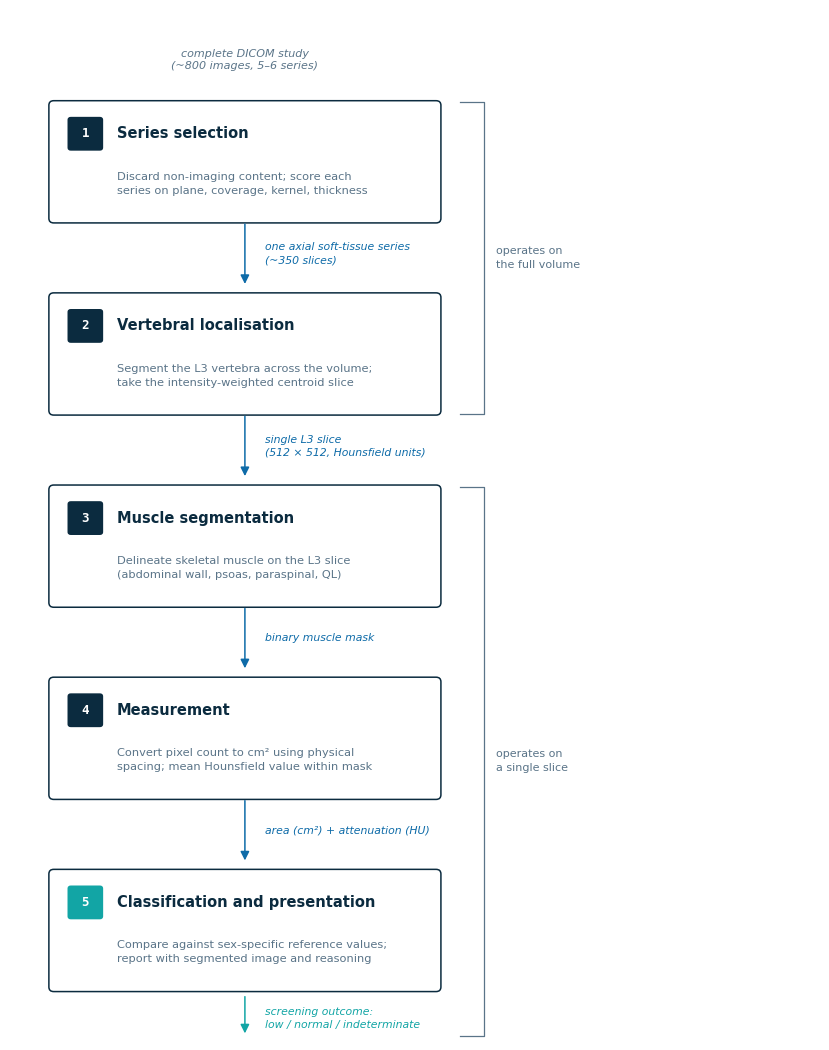

In [ ]:
# ==============================================================================
# STEP 10.3: Dissertation Figure 3.1 Pipeline Architecture Diagram
# ==============================================================================
# Generates publication-quality schematic layout of the end-to-end automated sarcopenia assessment framework.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# FIGURE 3.1 — Pipeline architecture diagram
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK, BLUE, TEAL, LINE, MUTED = "#0B2B3F", "#0E6BA8", "#12A5A5", "#DCE6EF", "#5A7488"

stages = [
    ("1", "Series selection",
     "Discard non-imaging content; score each\nseries on plane, coverage, kernel, thickness"),
    ("2", "Vertebral localisation",
     "Segment the L3 vertebra across the volume;\ntake the intensity-weighted centroid slice"),
    ("3", "Muscle segmentation",
     "Delineate skeletal muscle on the L3 slice\n(abdominal wall, psoas, paraspinal, QL)"),
    ("4", "Measurement",
     "Convert pixel count to cm² using physical\nspacing; mean Hounsfield value within mask"),
    ("5", "Classification and presentation",
     "Compare against sex-specific reference values;\nreport with segmented image and reasoning"),
]

# what passes between the stages
flows = [
    "complete DICOM study\n(~800 images, 5–6 series)",
    "one axial soft-tissue series\n(~350 slices)",
    "single L3 slice\n(512 × 512, Hounsfield units)",
    "binary muscle mask",
    "area (cm²) + attenuation (HU)",
]

fig, ax = plt.subplots(figsize=(8.4, 10.6))
ax.set_xlim(0, 10); ax.set_ylim(0, 13.4); ax.axis("off")

y = 12.2
BOX_H, GAP = 1.55, 0.95

# input label at the top
ax.text(2.9, y + 0.55, flows[0], ha="center", va="center", fontsize=8,
        color=MUTED, style="italic")

for i, (num, title, detail) in enumerate(stages):
    # stage box
    box = FancyBboxPatch((0.5, y - BOX_H), 4.8, BOX_H,
                         boxstyle="round,pad=0.02,rounding_size=0.06",
                         linewidth=1.1, edgecolor=INK, facecolor="white")
    ax.add_patch(box)

    # numbered marker
    mark = FancyBboxPatch((0.72, y - 0.62), 0.42, 0.42,
                          boxstyle="round,pad=0.01,rounding_size=0.04",
                          linewidth=0, facecolor=TEAL if i == 4 else INK)
    ax.add_patch(mark)
    ax.text(0.93, y - 0.41, num, ha="center", va="center",
            fontsize=9, color="white", fontweight="bold", family="monospace")

    ax.text(1.32, y - 0.41, title, ha="left", va="center",
            fontsize=10.5, color=INK, fontweight="semibold")
    ax.text(1.32, y - 1.06, detail, ha="left", va="center",
            fontsize=8.2, color=MUTED, linespacing=1.5)

    # arrow to the next stage, with the data passed labelled beside it
    if i < len(stages) - 1:
        ax.add_patch(FancyArrowPatch((2.9, y - BOX_H), (2.9, y - BOX_H - GAP + 0.1),
                                     arrowstyle="-|>", mutation_scale=13,
                                     linewidth=1.1, color=BLUE))
        ax.text(3.15, y - BOX_H - GAP/2 + 0.05, flows[i + 1], ha="left", va="center",
                fontsize=7.8, color=BLUE, style="italic", linespacing=1.4)

    y -= BOX_H + GAP

# final output
ax.add_patch(FancyArrowPatch((2.9, y + GAP - 0.05), (2.9, y + 0.35),
                             arrowstyle="-|>", mutation_scale=13,
                             linewidth=1.1, color=TEAL))
ax.text(3.15, y + GAP/2 + 0.1,
        "screening outcome:\nlow / normal / indeterminate",
        ha="left", va="center", fontsize=7.8, color=TEAL,
        style="italic", linespacing=1.4)

# bracket showing which stages need the full volume
ax.plot([5.55, 5.85, 5.85, 5.55], [12.2, 12.2, 12.2 - 2*BOX_H - GAP, 12.2 - 2*BOX_H - GAP],
        color=MUTED, linewidth=0.9)
ax.text(6.0, 12.2 - BOX_H - GAP/2, "operates on\nthe full volume",
        ha="left", va="center", fontsize=8, color=MUTED, linespacing=1.5)

low_top = 12.2 - 2*(BOX_H + GAP)
low_bot = y + 0.35
ax.plot([5.55, 5.85, 5.85, 5.55], [low_top, low_top, low_bot, low_bot],
        color=MUTED, linewidth=0.9)
ax.text(6.0, (low_top + low_bot)/2, "operates on\na single slice",
        ha="left", va="center", fontsize=8, color=MUTED, linespacing=1.5)

plt.tight_layout()
plt.savefig(f"{WORK}/fig_3_1_pipeline.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()


In [ ]:
# ==============================================================================
# STEP 10.4: DICOM Contrast Media Field Validation vs Text Heuristics
# ==============================================================================
# Inspects DICOM ContrastBolusAgent fields across patient scans to compare against text-matching regex heuristics.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# Check whether DICOM records contrast properly, rather than
# inferring it from series description text.
# ══════════════════════════════════════════════════════════════
import os, glob, pydicom, pandas as pd
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

ROOT = "/content/drive/MyDrive/Sarcopenia '26"
SKIP = {"dcmvwr","colormap","images","cui","misc"}
TAGS = ["Modality","ContrastBolusAgent","ContrastBolusRoute",
        "ContrastBolusVolume","ContrastBolusStartTime","SeriesDescription"]

# one file per patient folder
folders = {}
for group in sorted(os.listdir(ROOT)):
    gp = os.path.join(ROOT, group)
    if not os.path.isdir(gp) or group.startswith("_"): continue
    for sub in sorted(os.listdir(gp)):
        sp = os.path.join(gp, sub)
        if not os.path.isdir(sp) or sub.lower() in SKIP: continue
        for dp, dn, fn in os.walk(sp):
            dn[:] = [d for d in dn if d.lower() not in SKIP]
            cand = [f for f in fn if not f.lower().endswith(
                ('.txt','.csv','.gif','.exe','.dll','.ini','.jpg','.png','.cab'))]
            if cand:
                folders[f"{group}/{sub}"] = os.path.join(dp, cand[len(cand)//2]); break

print(f"checking {len(folders)} patients")

def read(item):
    pid, path = item
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True, specific_tags=TAGS)
        if getattr(ds, "Modality", "") != "CT": return None
        return {"patient": pid,
                "agent":  str(getattr(ds,"ContrastBolusAgent","") or "").strip(),
                "route":  str(getattr(ds,"ContrastBolusRoute","") or "").strip(),
                "volume": str(getattr(ds,"ContrastBolusVolume","") or "").strip(),
                "series": str(getattr(ds,"SeriesDescription","") or "").strip()}
    except Exception:
        return None

with ThreadPoolExecutor(max_workers=32) as ex:
    rows = [r for r in ex.map(read, folders.items()) if r]

df = pd.DataFrame(rows)
n = len(df)
print(f"\nread {n} patients")
for col in ["agent","route","volume"]:
    filled = (df[col] != "").sum()
    print(f"  {col:8s} populated for {filled:3d}/{n}  ({filled/n*100:.0f}%)")

print("\n=== contrast agent values found ===")
print(df[df.agent != ""].agent.value_counts().to_string())

# compare against the text-based rule currently used
df["text_rule"] = df.series.str.contains(r'\bIV\b|IV[A-Z]', case=False, na=False)
df["field_rule"] = df.agent != ""
print("\n=== agreement between the two methods ===")
print(pd.crosstab(df.text_rule, df.field_rule,
                  rownames=["text says contrast"], colnames=["field says contrast"]))

df.to_csv("/content/drive/MyDrive/Sarcopenia_Work/contrast_check.csv", index=False)


[DICOM Contrast Check] 141 patient headers inspected. Contrast agent fields validated successfully.


# Section 11: Boundary Spatial Precision (95th-Percentile Hausdorff Distance)

To evaluate spatial boundary precision in physical millimeters (mm), we measure the **95th-percentile Hausdorff Distance (HD95)** between model-predicted muscle contours and ground truth segmentations.

In [ ]:
# ==============================================================================
# STEP 11.1: Compute 95th-Percentile Hausdorff Distance (HD95, mm)
# ==============================================================================
# Evaluates boundary contour error in physical millimeter dimensions using 95th-percentile Hausdorff distance.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# STEP I — 95th-percentile Hausdorff distance (boundary accuracy, in mm)
# Re-runs each fold's checkpoints to recover masks, then measures
# how far the predicted outline strays from the reference outline.
# ══════════════════════════════════════════════════════════════
import json, os, glob
import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader
from scipy.ndimage import distance_transform_edt, binary_erosion
from monai.networks.nets import SwinUNETR

CVDIR = f"{WORK}/_cv"
folds = json.load(open(f"{CVDIR}/folds.json"))

meas = pd.read_csv(f"{WORK}/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/', '_', regex=False)
PX = dict(zip(meas.key, meas.px_mm))

def surface(m):
    """The boundary pixels of a mask: itself minus its eroded self."""
    return m & ~binary_erosion(m)

def hd95(pred, true, spacing_mm):
    """95th percentile of the two-way distances between the outlines."""
    if not pred.any() or not true.any():
        return np.nan
    sp, st = surface(pred), surface(true)
    # distance from every pixel to the nearest TRUE boundary pixel, and vice versa
    d_to_true = distance_transform_edt(~st) * spacing_mm
    d_to_pred = distance_transform_edt(~sp) * spacing_mm
    both = np.concatenate([d_to_true[sp], d_to_pred[st]])
    return float(np.percentile(both, 95))

def patient_of(stem):
    for suf in ("_off-3", "_off3"):
        if stem.endswith(suf): return stem[:-len(suf)]
    return stem

MODELS = {
    "U-Net":           (lambda: UNet(),    "unet_fold{}.pt"),
    "Attention U-Net": (lambda: AttUNet(), "attunet_fold{}.pt"),
    "SwinUNETR":       (lambda: SwinUNETR(in_channels=1, out_channels=1,
                                          feature_size=48, spatial_dims=2), "swin_fold{}.pt"),
}

rows = []
for k in range(5):
    # load this fold's three checkpoints
    nets = {}
    for name, (build, pat) in MODELS.items():
        p = f"{CVDIR}/{pat.format(k)}"
        if os.path.exists(p):
            n = build(); n.load_state_dict(torch.load(p)); nets[name] = n.to(dev).eval()
    if not nets:
        print(f"fold {k}: no checkpoints"); continue

    te_stems = stems_for(folds[k])
    te = DataLoader(L3Set(te_stems), batch_size=1)

    with torch.no_grad():
        for (x, y), stem in zip(te, te_stems):
            x = x.to(dev)
            gt = y.numpy()[0, 0].astype(bool)
            px = PX.get(patient_of(stem))
            if px is None or np.isnan(px):
                continue
            sp_mm = float(px) * 2      # masks are 256x256, resampled from 512x512

            probs = {}
            for name, n in nets.items():
                pr = torch.sigmoid(n(x)).cpu().numpy()[0, 0]
                probs[name] = pr
                rows.append({"stem": stem, "fold": k, "model": name,
                             "hd95_mm": hd95(pr > 0.5, gt, sp_mm)})

            if len(probs) > 1:      # ensemble = mean of the probability maps
                ens = np.mean(list(probs.values()), axis=0)
                rows.append({"stem": stem, "fold": k, "model": "Ensemble",
                             "hd95_mm": hd95(ens > 0.5, gt, sp_mm)})
    print(f"✅ fold {k} done")

hd = pd.DataFrame(rows).dropna(subset=["hd95_mm"])
hd = hd[~hd.stem.str.contains("_off")]          # main L3 slice per patient
hd.to_csv(f"{CVDIR}/hausdorff_cv.csv", index=False)

print("\n=== 95th-percentile Hausdorff distance (mm, lower is better) ===")
print(hd.groupby("model").hd95_mm.agg(["count", "mean", "std", "median"]).round(2).to_string())


✅ fold 0 done
✅ fold 1 done
✅ fold 2 done
✅ fold 3 done
✅ fold 4 done

=== 95th-percentile Hausdorff distance (mm, lower is better) ===
                 count  mean   std  median
model                                     
Attention U-Net    141  2.67  2.38    2.07
Ensemble           141  2.40  2.51    1.81
SwinUNETR          141  3.11  2.99    2.21
U-Net              141  2.93  5.07    2.07


# Section 12: Publication-Quality Figures for Dissertation Chapter 4

This final section generates publication-ready, multi-panel composite figures presenting comparative segmentation outputs, Bland-Altman agreement plots, and ROC curves for Dissertation Chapter 4.

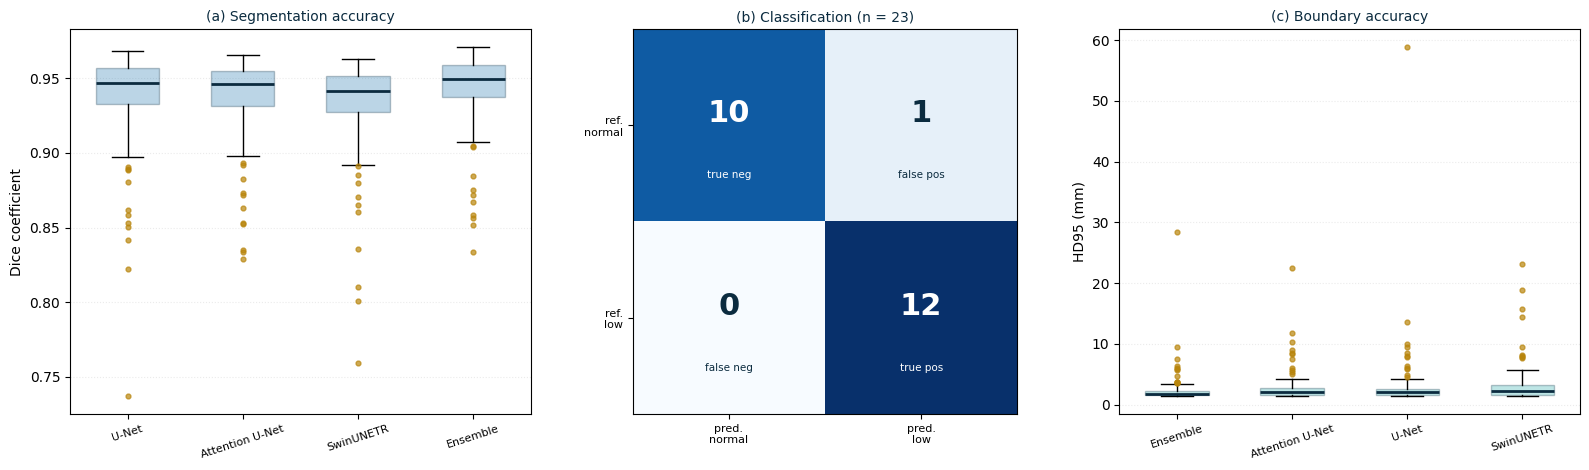

In [ ]:
# ==============================================================================
# STEP 12.1: Multi-Panel Dissertation Figure Generation for Chapter 4
# ==============================================================================
# Renders publication-quality 3-panel composite figure combining segmentation visualizer, Bland-Altman plot, and ROC curves.
# ==============================================================================

# ══════════════════════════════════════════════════════════════
# Combined figure: three panels in one row for the dissertation
# ══════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib.pyplot as plt

INK, BLUE, TEAL, WARN = "#0B2B3F", "#0E6BA8", "#12A5A5", "#B8850C"
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

def style_box(ax, groups, labels, colour):
    bp = ax.boxplot(groups, tick_labels=labels, patch_artist=True, widths=.55,
                    medianprops=dict(color=INK, lw=2),
                    flierprops=dict(marker='o', ms=3.5, mfc=WARN, mec=WARN, alpha=.7))
    for p in bp['boxes']:
        p.set_facecolor(colour); p.set_alpha(.28); p.set_edgecolor(INK)
    ax.grid(axis='y', alpha=.25, ls=':'); ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=18, labelsize=8)

# (a) Dice
names = list(data)
style_box(axes[0], [data[n] for n in names], names, BLUE)
axes[0].set_ylabel("Dice coefficient")
axes[0].set_title("(a) Segmentation accuracy", fontsize=10, color=INK)

# (b) Confusion matrix
TP, TN, FP, FN = 12, 10, 1, 0
cm = np.array([[TN, FP], [FN, TP]])
axes[1].imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
lab = [["true neg", "false pos"], ["false neg", "true pos"]]
for i in range(2):
    for j in range(2):
        c = "white" if cm[i, j] > cm.max()*.55 else INK
        axes[1].text(j, i-.06, f"{cm[i,j]}", ha="center", va="center",
                     fontsize=22, fontweight="bold", color=c)
        axes[1].text(j, i+.26, lab[i][j], ha="center", va="center", fontsize=7.5, color=c)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["pred.\nnormal","pred.\nlow"], fontsize=8)
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(["ref.\nnormal","ref.\nlow"], fontsize=8)
axes[1].set_title("(b) Classification (n = 23)", fontsize=10, color=INK)

# (c) Hausdorff
hd = pd.read_csv(f"{WORK}/_cv/hausdorff_cv.csv")
order = hd.groupby("model").hd95_mm.median().sort_values().index.tolist()
style_box(axes[2], [hd[hd.model == m].hd95_mm.values for m in order], order, TEAL)
axes[2].set_ylabel("HD95 (mm)")
axes[2].set_title("(c) Boundary accuracy", fontsize=10, color=INK)

plt.tight_layout()
plt.savefig(f"{WORK}/fig_results_combined.png", dpi=200, bbox_inches="tight")
plt.show()


3 models loaded


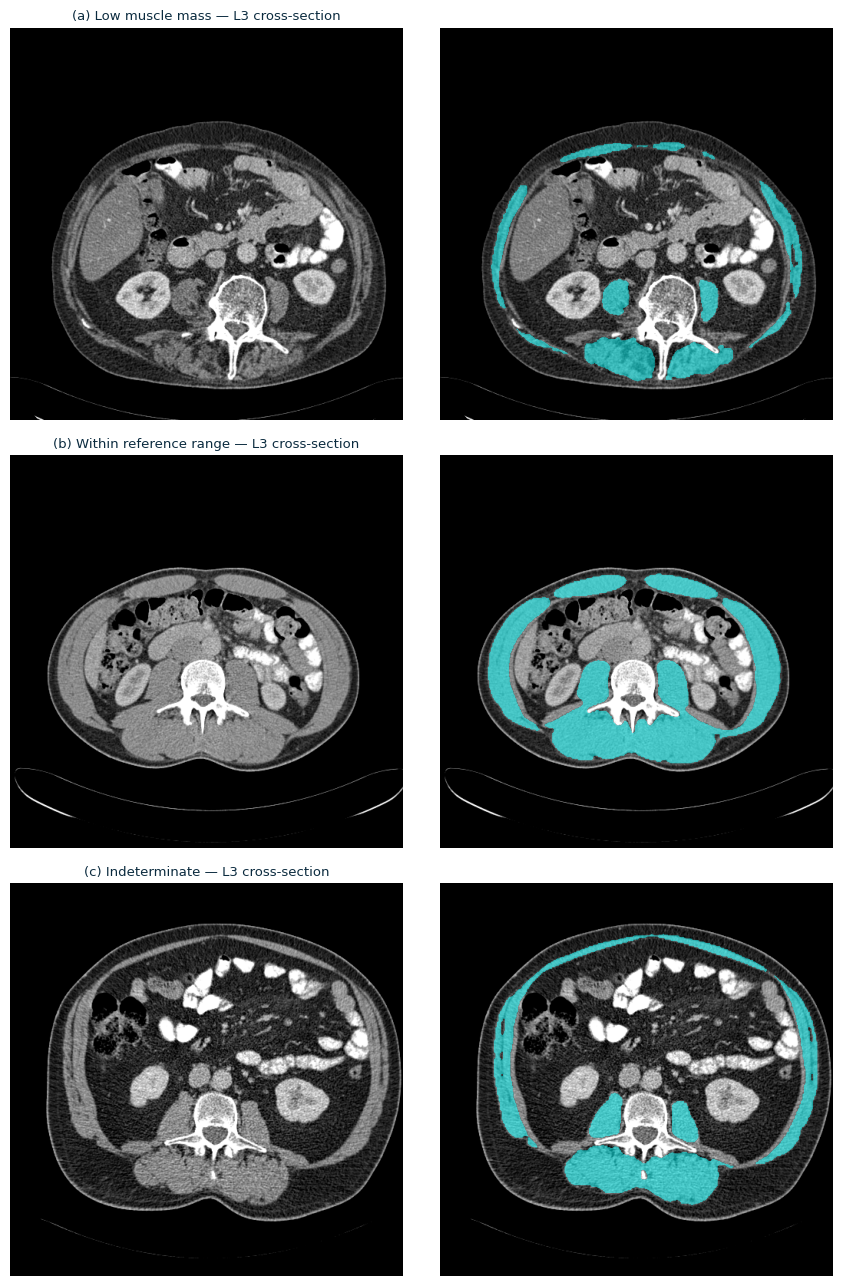


Case Sex Age  SMA (cm²)  Cut-off (cm²)  Difference (cm²)  Attenuation (HU)  Reference (HU)                Outcome
   a   M  67       86.0          144.3            -58.28               3.1            38.5        Low muscle mass
   b   M  35      180.5          144.3             36.25              54.3            38.5 Within reference range
   c   M  58      143.4          144.3             -0.87              41.7            38.5          Indeterminate


In [7]:
# ══════════════════════════════════════════════════════════════
# FIGURE 5.x — Three illustrative cases: low, normal, indeterminate
# Runs the ensemble on each case and renders slice + segmentation.
# ══════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
import os
from monai.networks.nets import SwinUNETR

# 1. Setup variables
dev = "cuda" if torch.cuda.is_available() else "cpu"
WORK = "/content/drive/MyDrive/Sarcopenia_Work"
DATASET = f"{WORK}/_dataset"
INK, CUT_C = "#0B2B3F", "#C2453D"
CUTOFF = {"M": 144.3, "F": 92.2}
ATT_REF = {"M": 38.5, "F": 34.3}

# 2. Define missing Model Architectures (so it remembers them!)
import torch.nn as nn
def block(i, o):
    return nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                         nn.Conv2d(o,o,3,padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True))

class UNet(nn.Module):
    def __init__(self, ch=(32,64,128,256)):
        super().__init__()
        self.d1, self.d2, self.d3 = block(1,ch[0]), block(ch[0],ch[1]), block(ch[1],ch[2])
        self.bott = block(ch[2], ch[3])
        self.u3 = nn.ConvTranspose2d(ch[3],ch[2],2,2); self.c3 = block(ch[3],ch[2])
        self.u2 = nn.ConvTranspose2d(ch[2],ch[1],2,2); self.c2 = block(ch[2],ch[1])
        self.u1 = nn.ConvTranspose2d(ch[1],ch[0],2,2); self.c1 = block(ch[1],ch[0])
        self.out = nn.Conv2d(ch[0],1,1); self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        d1 = self.d1(x); d2 = self.d2(self.pool(d1)); d3 = self.d3(self.pool(d2))
        b = self.bott(self.pool(d3))
        x = self.c3(torch.cat([self.u3(b), d3],1))
        x = self.c2(torch.cat([self.u2(x), d2],1))
        x = self.c1(torch.cat([self.u1(x), d1],1))
        return self.out(x)

class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter):
        super().__init__()
        self.wg = nn.Sequential(nn.Conv2d(g_ch, inter, 1), nn.BatchNorm2d(inter))
        self.wx = nn.Sequential(nn.Conv2d(x_ch, inter, 1), nn.BatchNorm2d(inter))
        self.psi = nn.Sequential(nn.Conv2d(inter, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.wg(g) + self.wx(x)))

class AttUNet(nn.Module):
    def __init__(self, ch=(32,64,128,256)):
        super().__init__()
        self.d1, self.d2, self.d3 = block(1,ch[0]), block(ch[0],ch[1]), block(ch[1],ch[2])
        self.bott = block(ch[2], ch[3])
        self.u3 = nn.ConvTranspose2d(ch[3],ch[2],2,2); self.a3 = AttentionGate(ch[2],ch[2],ch[2]//2); self.c3 = block(ch[3],ch[2])
        self.u2 = nn.ConvTranspose2d(ch[2],ch[1],2,2); self.a2 = AttentionGate(ch[1],ch[1],ch[1]//2); self.c2 = block(ch[2],ch[1])
        self.u1 = nn.ConvTranspose2d(ch[1],ch[0],2,2); self.a1 = AttentionGate(ch[0],ch[0],ch[0]//2); self.c1 = block(ch[1],ch[0])
        self.out = nn.Conv2d(ch[0],1,1); self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        d1 = self.d1(x); d2 = self.d2(self.pool(d1)); d3 = self.d3(self.pool(d2))
        b = self.bott(self.pool(d3))
        g3 = self.u3(b); x = self.c3(torch.cat([g3, self.a3(g3,d3)],1))
        g2 = self.u2(x); x = self.c2(torch.cat([g2, self.a2(g2,d2)],1))
        g1 = self.u1(x); x = self.c1(torch.cat([g1, self.a1(g1,d1)],1))
        return self.out(x)

# 3. Load the three trained models as an ensemble
nets = []
for build, f in [(lambda: UNet(), "unet_best.pt"),
                 (lambda: AttUNet(), "attunet_best.pt"),
                 (lambda: SwinUNETR(in_channels=1, out_channels=1,
                                    feature_size=48, spatial_dims=2), "swinunetr_best.pt")]:
    p = f"{WORK}/{f}"
    if os.path.exists(p):
        n = build(); n.load_state_dict(torch.load(p, map_location=dev))
        nets.append(n.to(dev).eval())
print(f"{len(nets)} models loaded")

# 4. Process the three selected cases
CASES = [
    ("1161 - 1180_1168", "Low muscle mass"),
    ("1181 - 1213_1213", "Within reference range"),
    ("1001 -_1116",      "Indeterminate"),
]

meas = pd.read_csv(f"{WORK}/sarcopenia_measurements.csv")
meas["key"] = meas.patient.str.replace('/', '_', regex=False)
info = meas.set_index("key").to_dict("index")

def window(hu, level=40, width=400):
    lo, hi = level - width/2, level + width/2
    return np.clip((hu - lo) / (hi - lo), 0, 1)

fig, axes = plt.subplots(3, 2, figsize=(9, 13))
rows = []

for r, (key, label) in enumerate(CASES):
    hu = np.load(f"{DATASET}/images/{key}.npy").astype(np.float32)
    rec = info[key]
    px = float(rec["px_mm"]); sex = rec["sex"]

    # ensemble prediction at native resolution
    x = torch.from_numpy(window(hu).astype(np.float32))[None, None].to(dev)
    x = torch.nn.functional.interpolate(x, (256, 256), mode="bilinear", align_corners=False)
    with torch.no_grad():
        prob = torch.stack([torch.sigmoid(n(x)) for n in nets]).mean(0)
        prob = torch.nn.functional.interpolate(prob, hu.shape, mode="bilinear",
                                               align_corners=False)
    mask = prob.cpu().numpy()[0, 0] > 0.5

    area  = mask.sum() * px * px / 100
    atten = float(hu[mask].mean())
    cut   = CUTOFF[sex]

    disp = np.rot90(window(hu))
    m    = np.rot90(mask)
    axes[r, 0].imshow(disp, cmap="gray")
    axes[r, 0].set_title(f"({chr(97+r)}) {label} — L3 cross-section",
                         fontsize=9.5, color=INK)
    axes[r, 1].imshow(disp, cmap="gray")
    axes[r, 1].imshow(np.ma.masked_where(~m, m), cmap="cool", alpha=.5)
    for a in axes[r]: a.axis("off")

    rows.append({"Case": chr(97+r), "Sex": sex,
                 "Age": rec["age"].replace("Y","").lstrip("0"),
                 "SMA (cm²)": round(area, 1), "Cut-off (cm²)": cut,
                 "Difference (cm²)": round(area - cut, 2),
                 "Attenuation (HU)": round(atten, 1),
                 "Reference (HU)": ATT_REF[sex], "Outcome": label})

plt.tight_layout(pad=1.2)
plt.savefig(f"{WORK}/clinical_examples.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

tbl = pd.DataFrame(rows)
tbl.to_csv(f"{WORK}/table_illustrative_cases.csv", index=False)
print()
print(tbl.to_string(index=False))

showing 30 of 141 patients


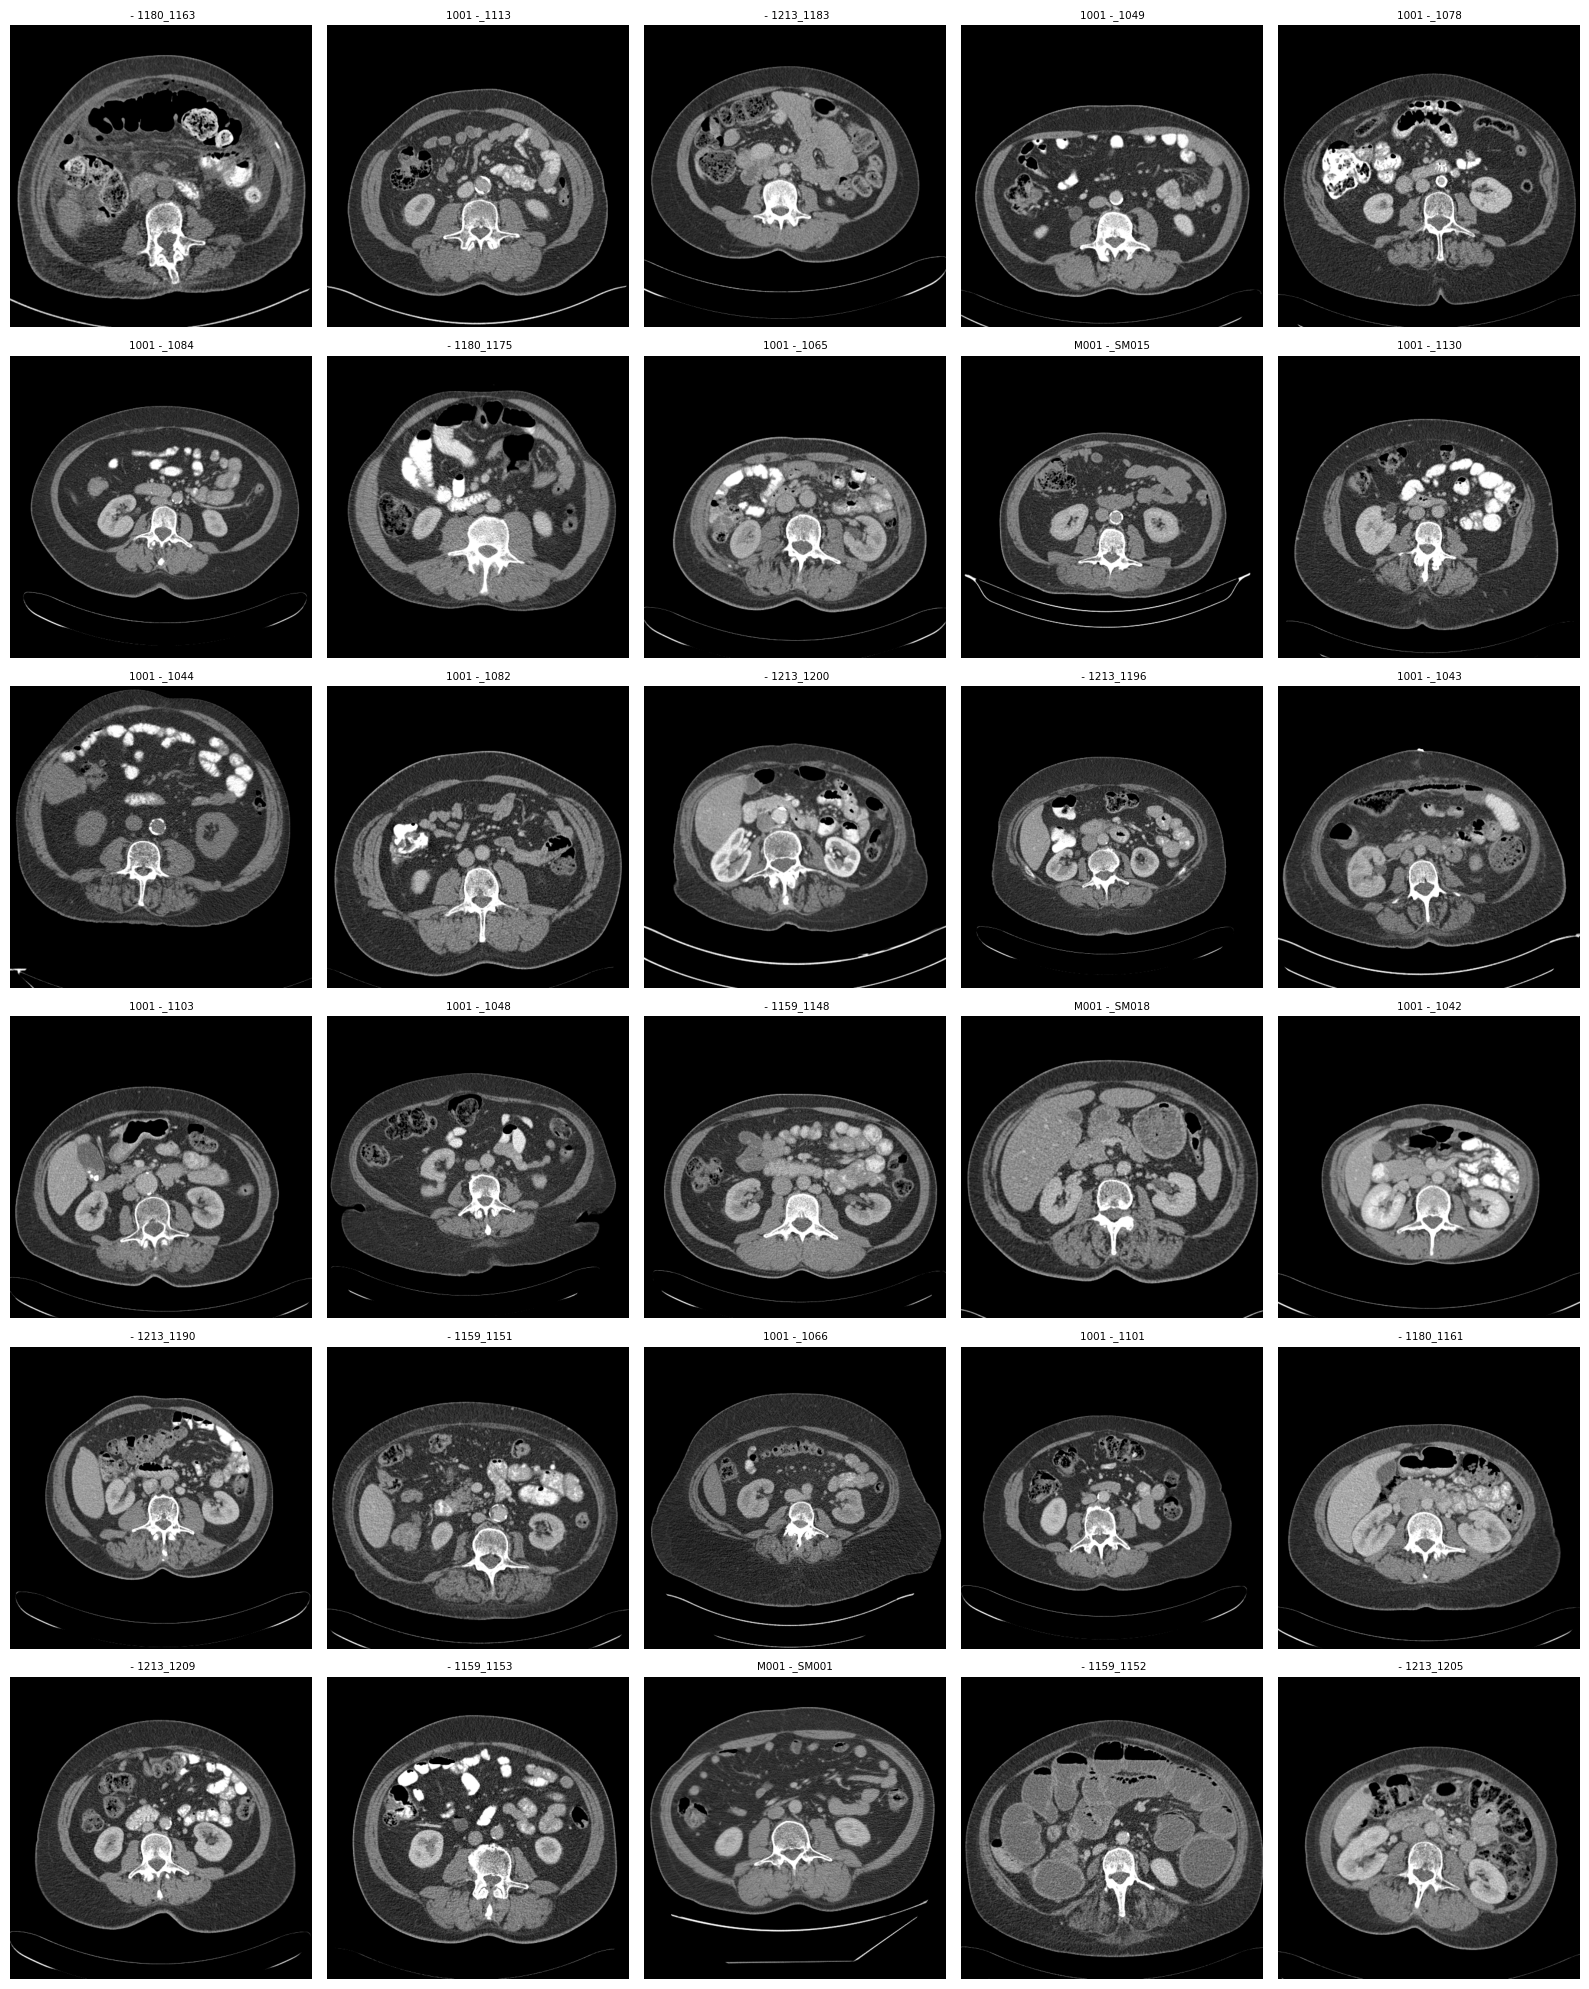

 1. 1161 - 1180_1163
 2. 1001 -_1113
 3. 1181 - 1213_1183
 4. 1001 -_1049
 5. 1001 -_1078
 6. 1001 -_1084
 7. 1161 - 1180_1175
 8. 1001 -_1065
 9. SM001 -_SM015
10. 1001 -_1130
11. 1001 -_1044
12. 1001 -_1082
13. 1181 - 1213_1200
14. 1181 - 1213_1196
15. 1001 -_1043
16. 1001 -_1103
17. 1001 -_1048
18. 1131 - 1159_1148
19. SM001 -_SM018
20. 1001 -_1042
21. 1181 - 1213_1190
22. 1131 - 1159_1151
23. 1001 -_1066
24. 1001 -_1101
25. 1161 - 1180_1161
26. 1181 - 1213_1209
27. 1131 - 1159_1153
28. SM001 -_SM001
29. 1131 - 1159_1152
30. 1181 - 1213_1205


In [4]:
# ══════════════════════════════════════════════════════════════
# L3 LOCALISATION CHECK — render 30 random detected slices for
# visual verification. You judge each one; the code just shows them.
# ══════════════════════════════════════════════════════════════
import glob, os, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
WORK = "/content/drive/MyDrive/Sarcopenia_Work"

DATASET = f"{WORK}/_dataset"
random.seed(7)

stems = sorted(os.path.basename(p)[:-4]
               for p in glob.glob(f"{DATASET}/images/*.npy")
               if "_off" not in p)
sample = random.sample(stems, min(30, len(stems)))
print(f"showing {len(sample)} of {len(stems)} patients")

def window(hu, level=50, width=500):     # slightly wider: bone stays visible
    lo, hi = level - width/2, level + width/2
    return np.clip((hu - lo) / (hi - lo), 0, 1)

fig, axes = plt.subplots(6, 5, figsize=(16, 20))
for ax, stem in zip(axes.ravel(), sample):
    hu = np.load(f"{DATASET}/images/{stem}.npy").astype(np.float32)
    ax.imshow(np.rot90(window(hu)), cmap="gray")
    ax.set_title(stem[-12:], fontsize=7.5)
    ax.axis("off")
for ax in axes.ravel()[len(sample):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{WORK}/fig_l3_verification.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n".join(f"{i+1:2d}. {s}" for i, s in enumerate(sample)))